# 파생변수(derived features) 심화 EDA

> **기존 `EDA.ipynb`는 원본 데이터**(발화점 분포·dNBR·기상관측소)만 봤다. 이 노트북은 **모델이 실제 쓰는 파생변수**를 EDA 한다 — 사전 엔지니어링 피처 + pfire 로 재계산한 중간변수(발화 I·체제 게이트·기상 W·확산 S·위험 R)·제출물 컬럼.

로직은 `scripts/eda_derived.py`(단일 진실)에 있고, 이 노트북은 그 섹션 함수를 import 해 섹션별로 돌리며 그림을 인라인으로 본다. 그림 원본은 `outputs/figures/eda/`.

**핵심 결론(미리)**: ① 단일 파생변수 분리력 전부 약함(AUC-PR lift 1.5~1.9×) → recall 천장은 피처 한계. ② 영동 95% 쏠림의 기계적 원인 = W(영동/비영동 2.42×). ③ FWI 3종·s2 다중공선성. ④ `unc_lo` 상수0(죽은 컬럼).

## 0. 셋업 — 파생변수 행렬 구성 (pfire 로 I·S·W·R 재계산 + 제출물 + 발화점 앵커)

In [1]:
import sys
from pathlib import Path
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT/'scripts'/'eda_derived.py').exists() and (ROOT.parent/'scripts'/'eda_derived.py').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT/'scripts'))
import eda_derived as E

def show(*names):
    for n in names:
        display(Image(filename=str(E.FIG_DIR / n)))

D = E.build_frame()
cols, grp = E.assemble_feature_matrix(D)
print(f'파생변수 {len(cols)}개 · 전주 {len(next(iter(cols.values()))):,}개')

[load] master frame ...
[model] gate / I / per-expert ...
[model] W (blended season×daily) / S / R ...
[anchor] positives → poles ...


파생변수 46개 · 전주 1,387,831개


## 1. 분포·요약 — 퇴화(상수/극왜곡) 변수 flag
각 파생변수의 분포·결측·%zero. `unc_lo`처럼 정보 없는 컬럼을 잡아낸다.

[sec1] distributions & summary


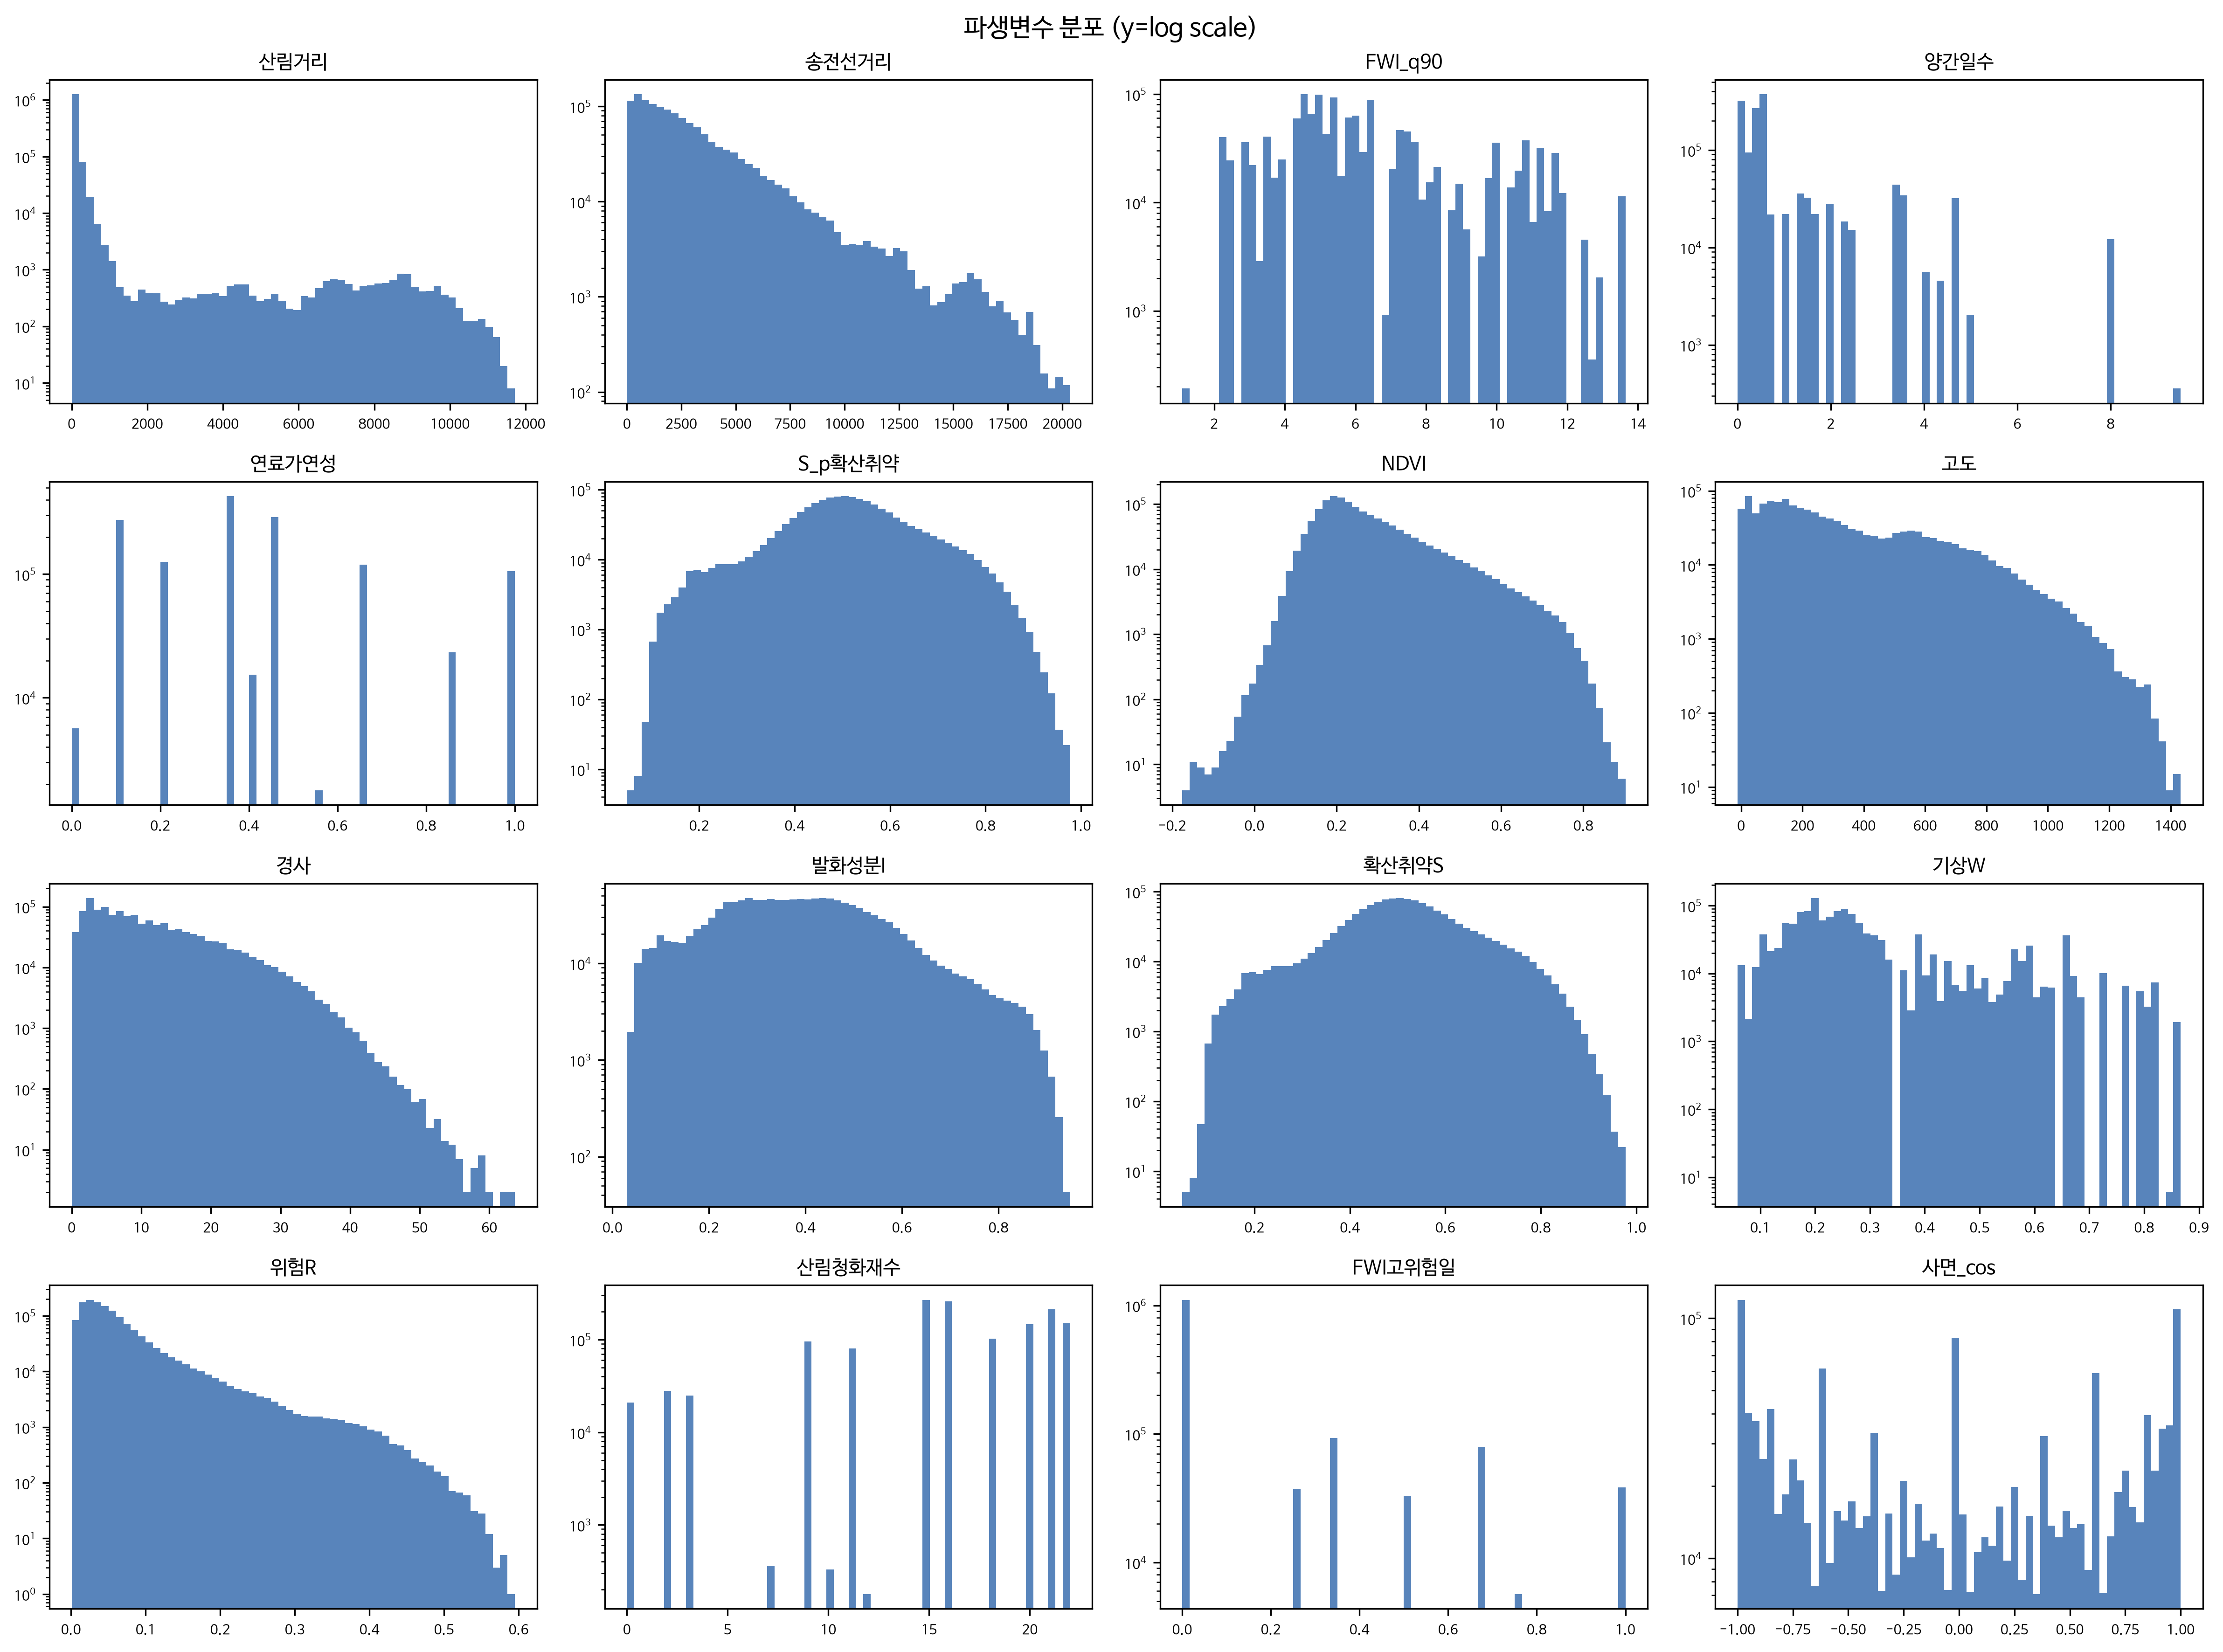

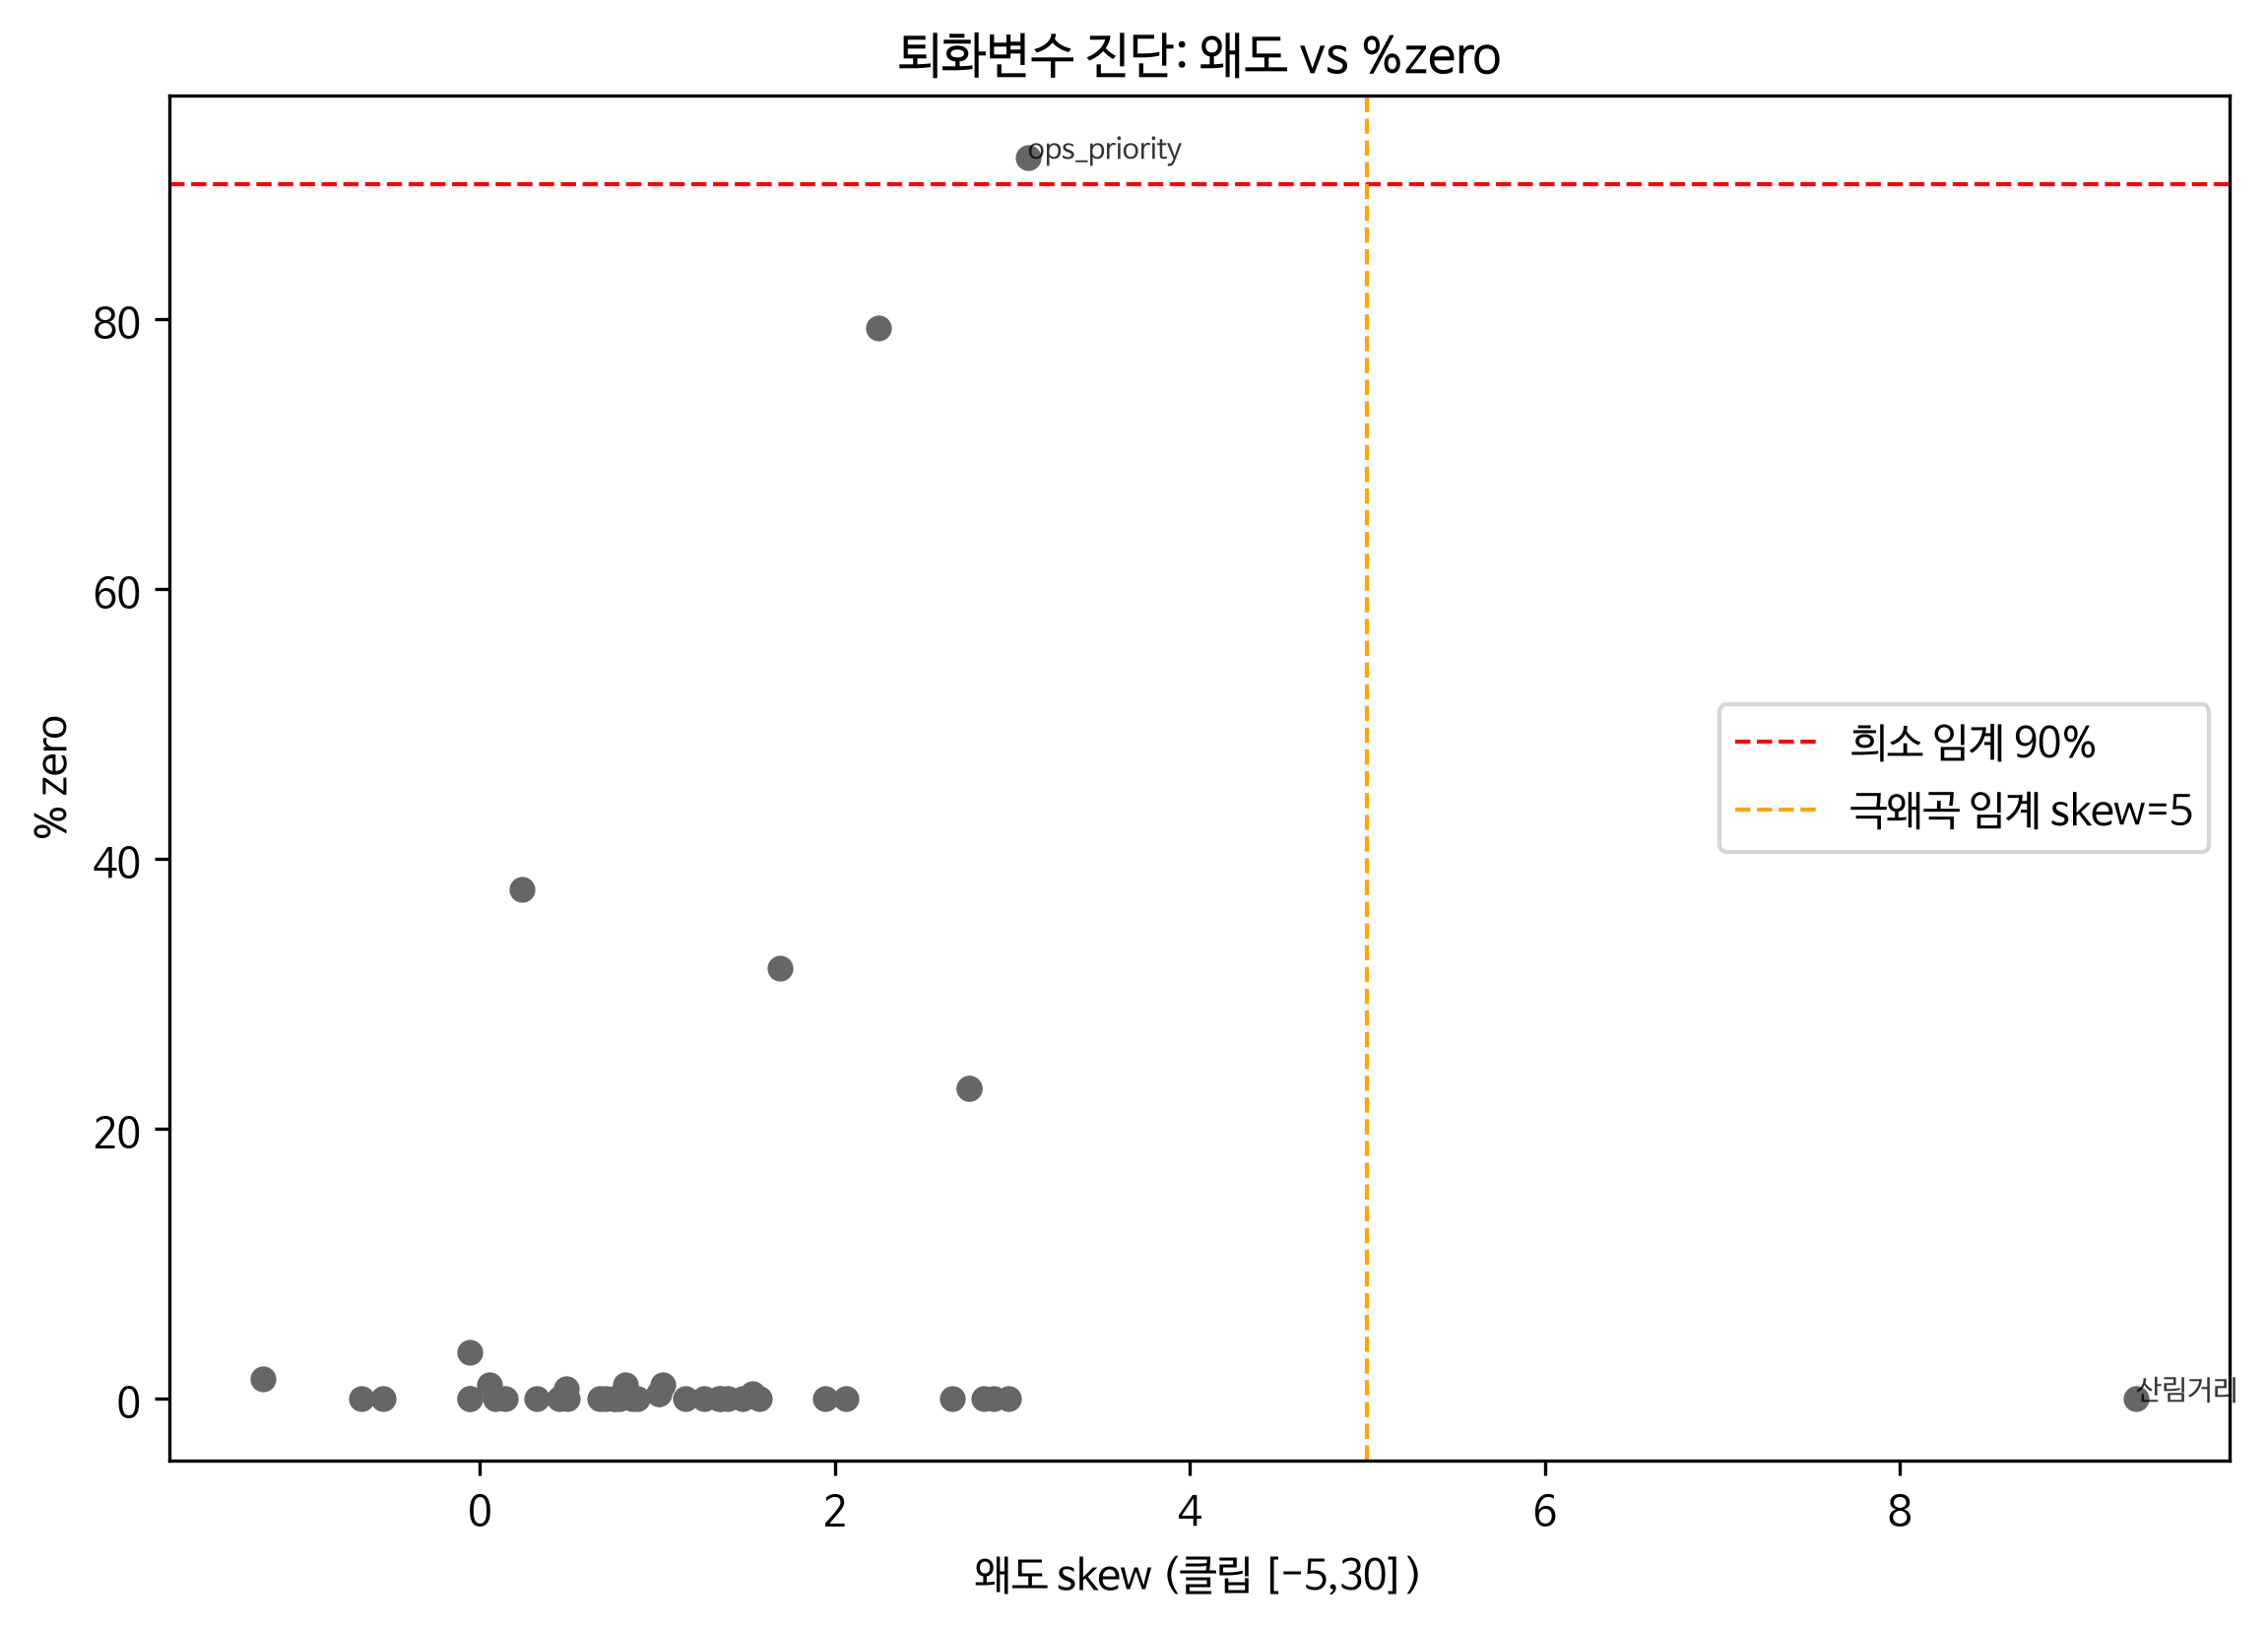

In [2]:
s1 = E.section1_distributions(cols, grp)
show('01_distributions.png', '01_degeneracy_scatter.png')

## 2. 상관·다중공선성 — 중복 변수 찾기
dist_to_forest↔토지피복(산림), fwi_q90↔fwi_mean, s2_nbr↔s2_ndmi 등 거울/중복쌍·VIF.

[sec2] correlation & multicollinearity


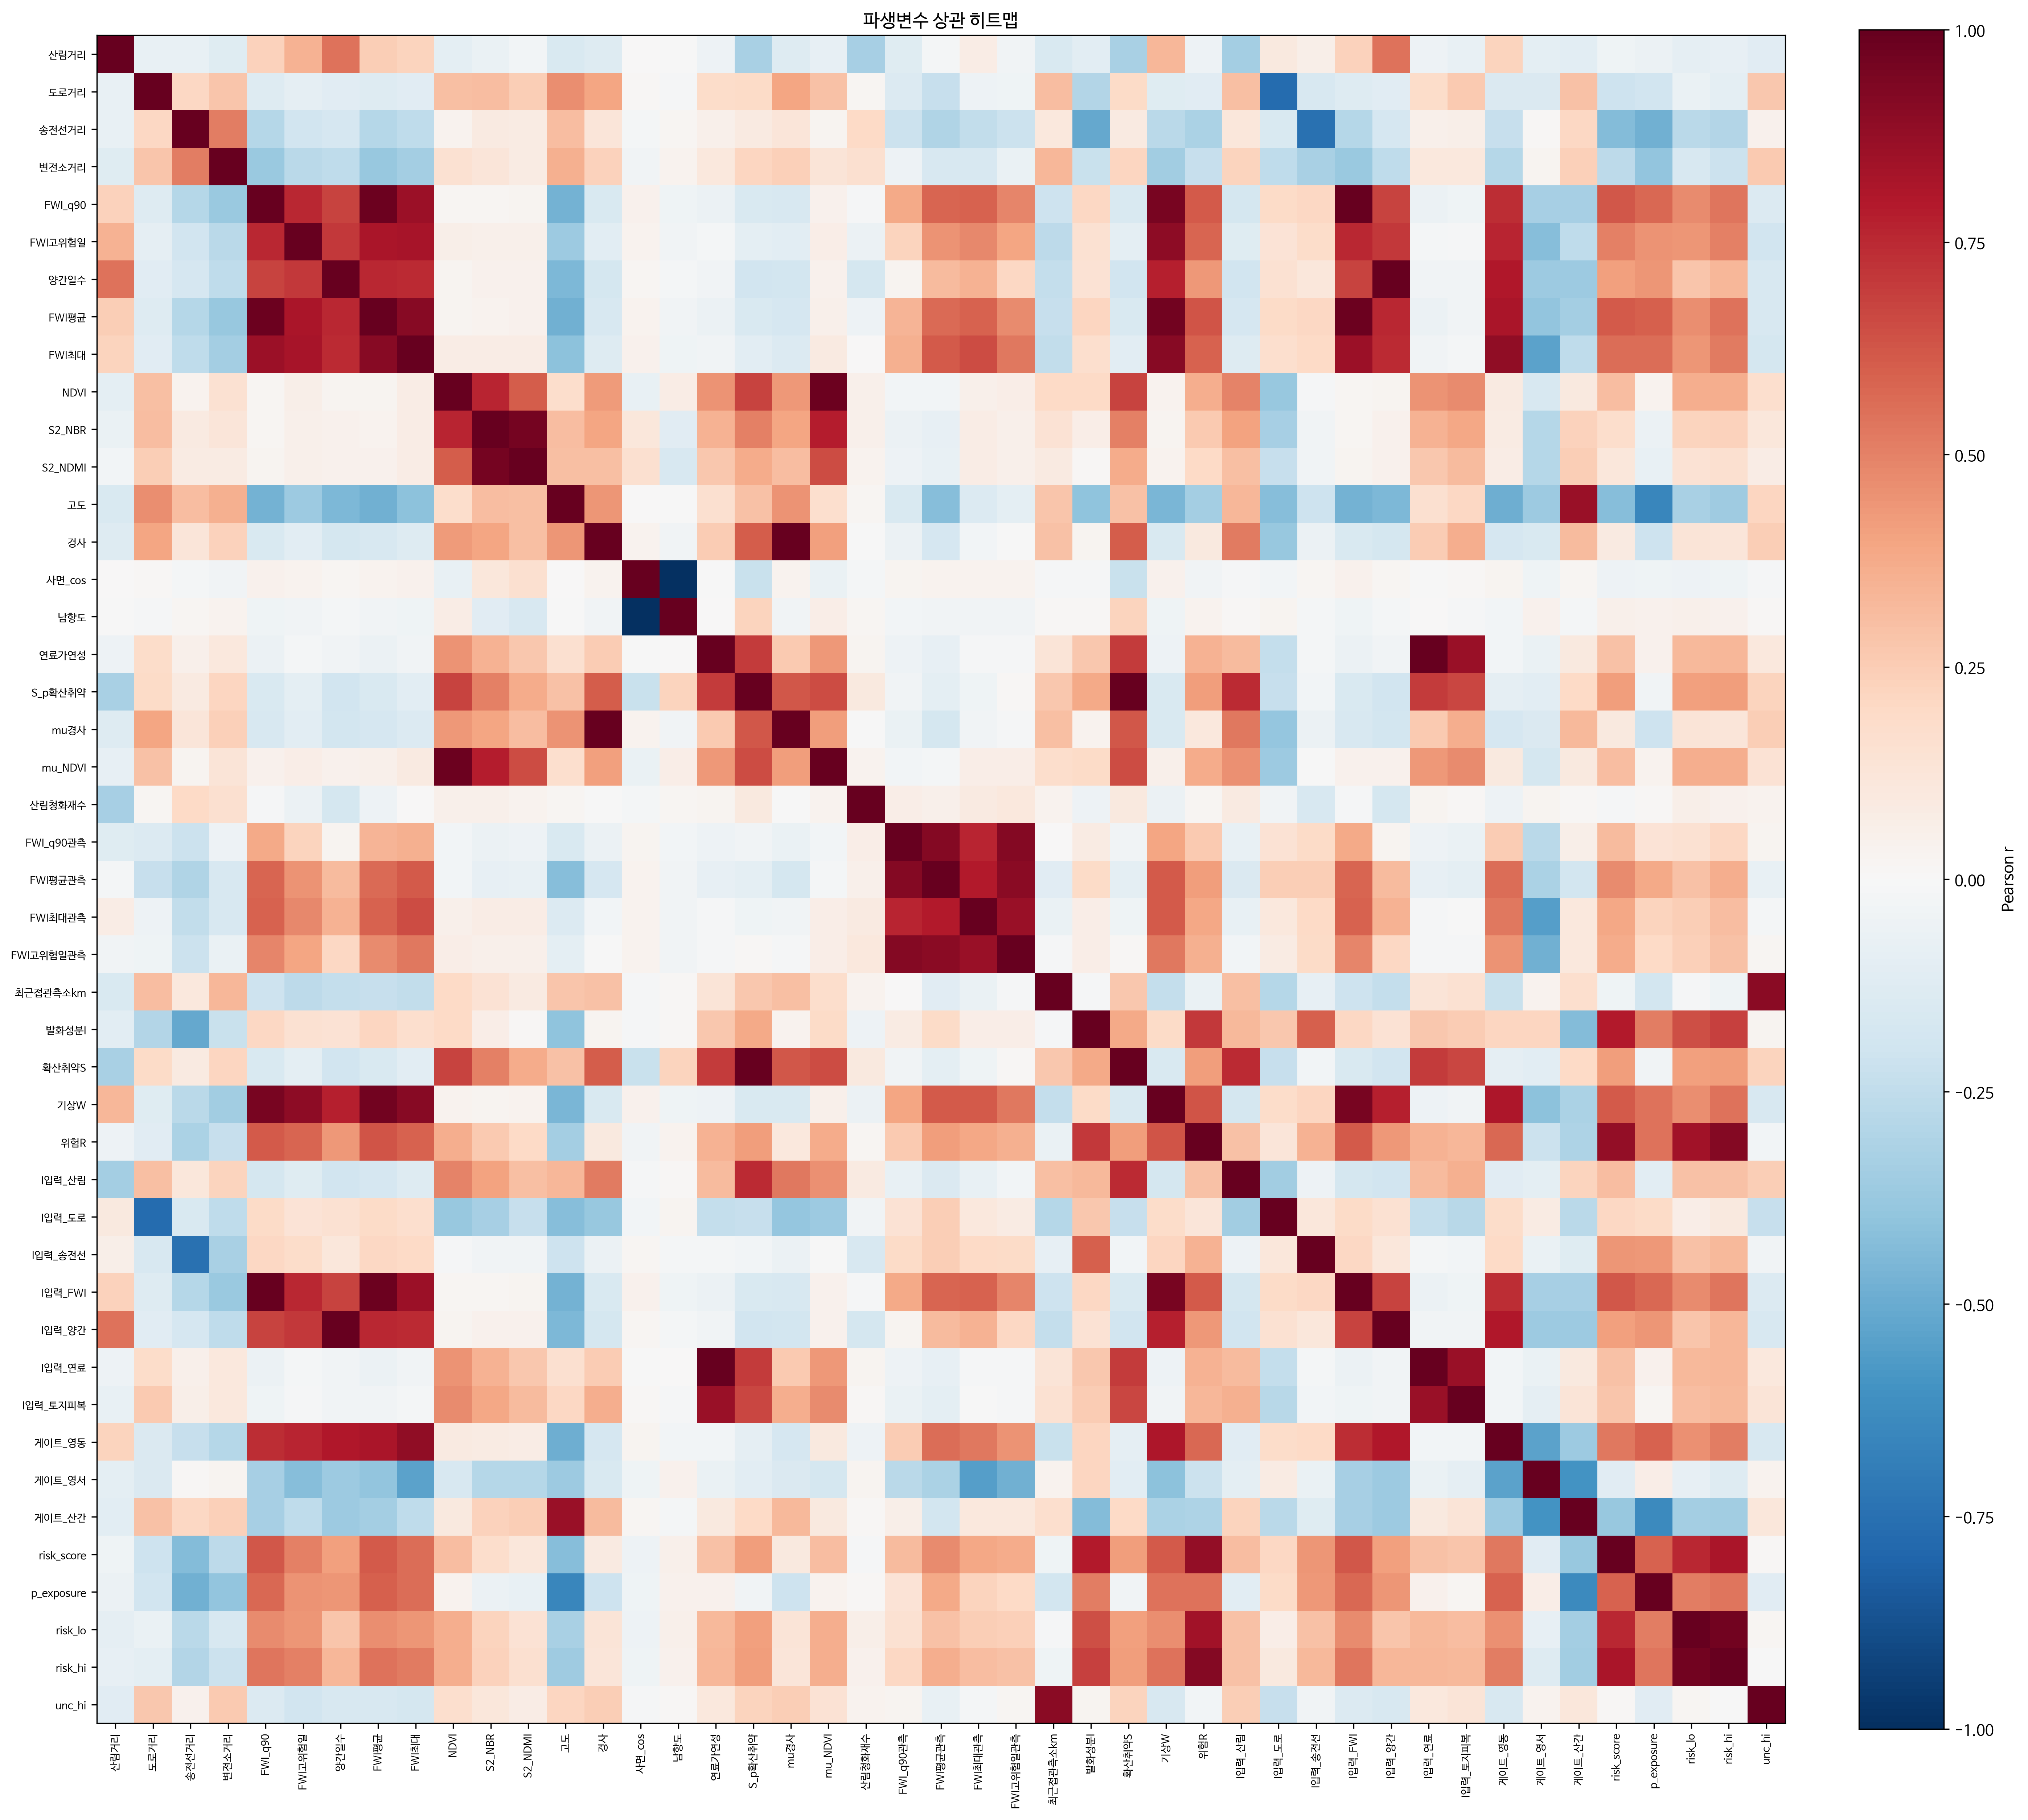

[고상관쌍 |r|>=0.8]
  fwi_q90 <-> fwi_mean : r=+0.977
  fwi_mean <-> W : r=+0.966
  risk_lo <-> risk_hi : r=+0.961
  s2_nbr <-> s2_ndmi : r=+0.957
  fwi_q90 <-> W : r=+0.949
  W <-> f_fwi : r=+0.949
  fwi_q90_obs <-> fwi_hdd_obs : r=+0.919
  R <-> risk_hi : r=+0.918
  fwi_q90_obs <-> fwi_mean_obs : r=+0.915
  fwi_mean <-> fwi_max : r=+0.910


In [3]:
s2 = E.section2_correlation(cols, grp)
show('02_corr_heatmap.png')
print('[고상관쌍 |r|>=0.8]')
for a,b,r in s2['hi_pairs'][:10]:
    print(f'  {a} <-> {b} : r={r:+.3f}')

## 3. 발화 분리력 (핵심) — 어떤 파생변수가 실제 발화를 가르나
변수별 AUC-PR·KS·point-biserial. 발화점은 앵커로만(학습 미사용). **단일변수 판별력 순위표.**

[sec3] per-feature separability (anchors=positives)


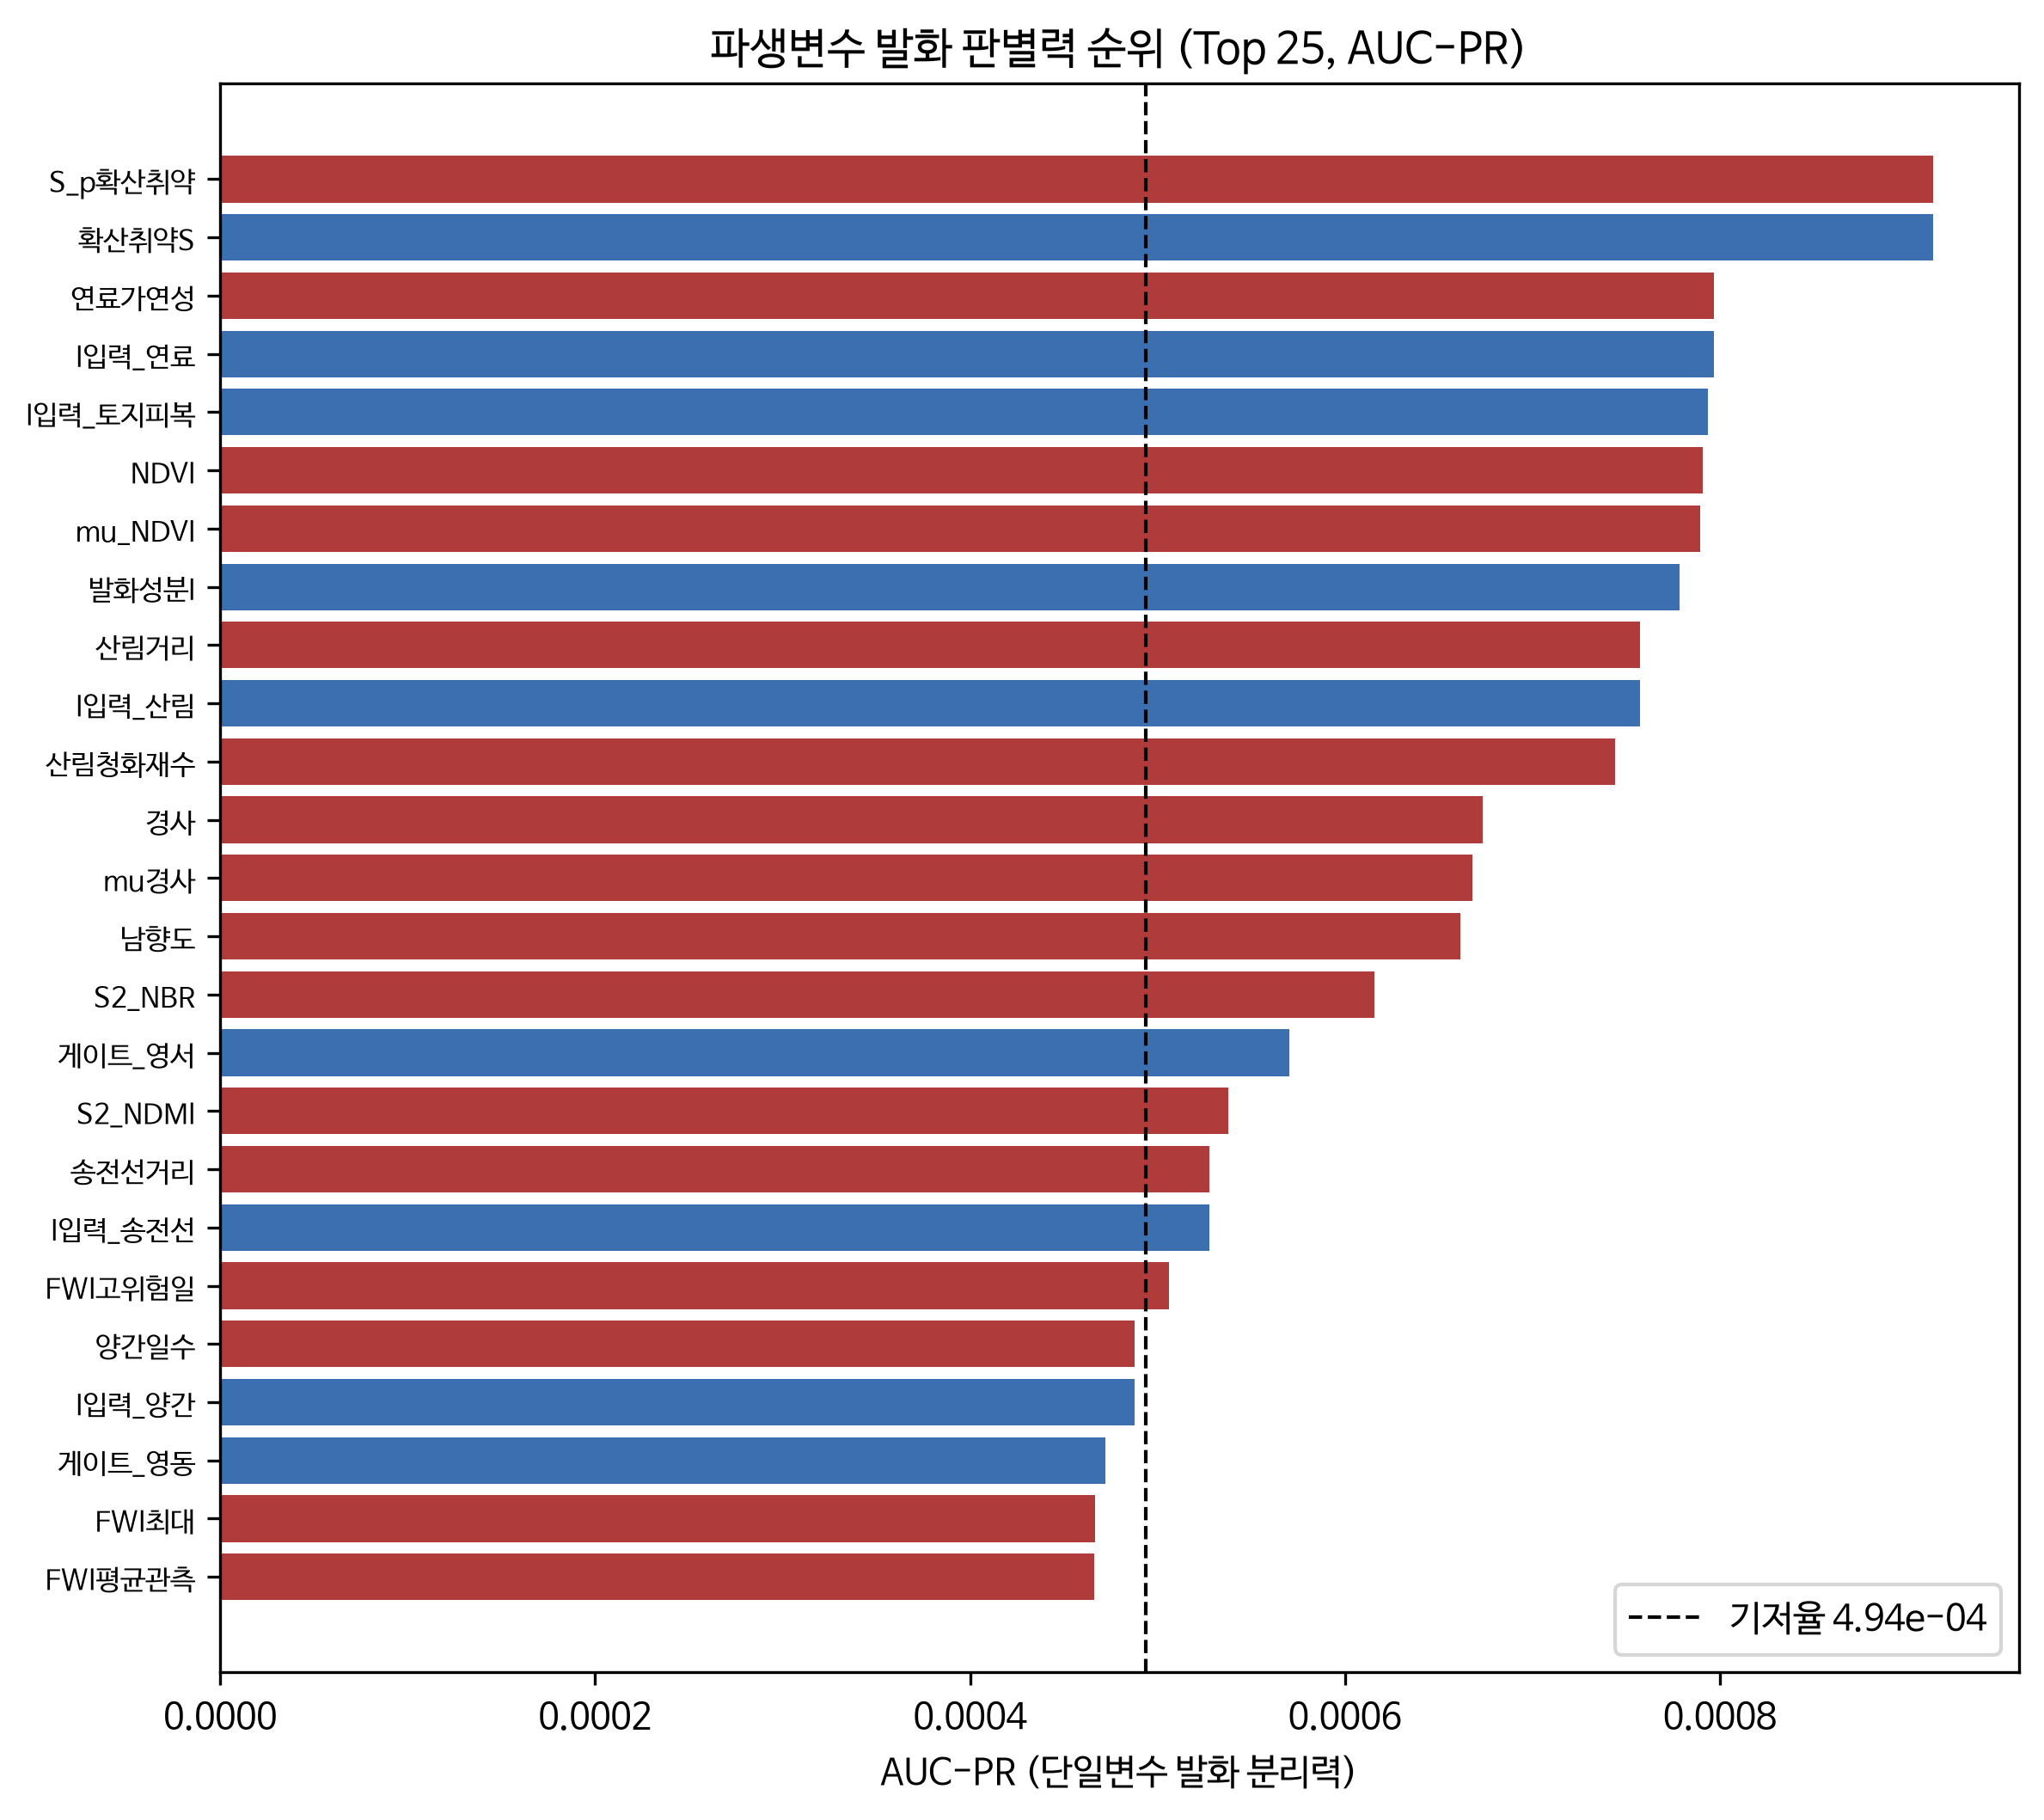

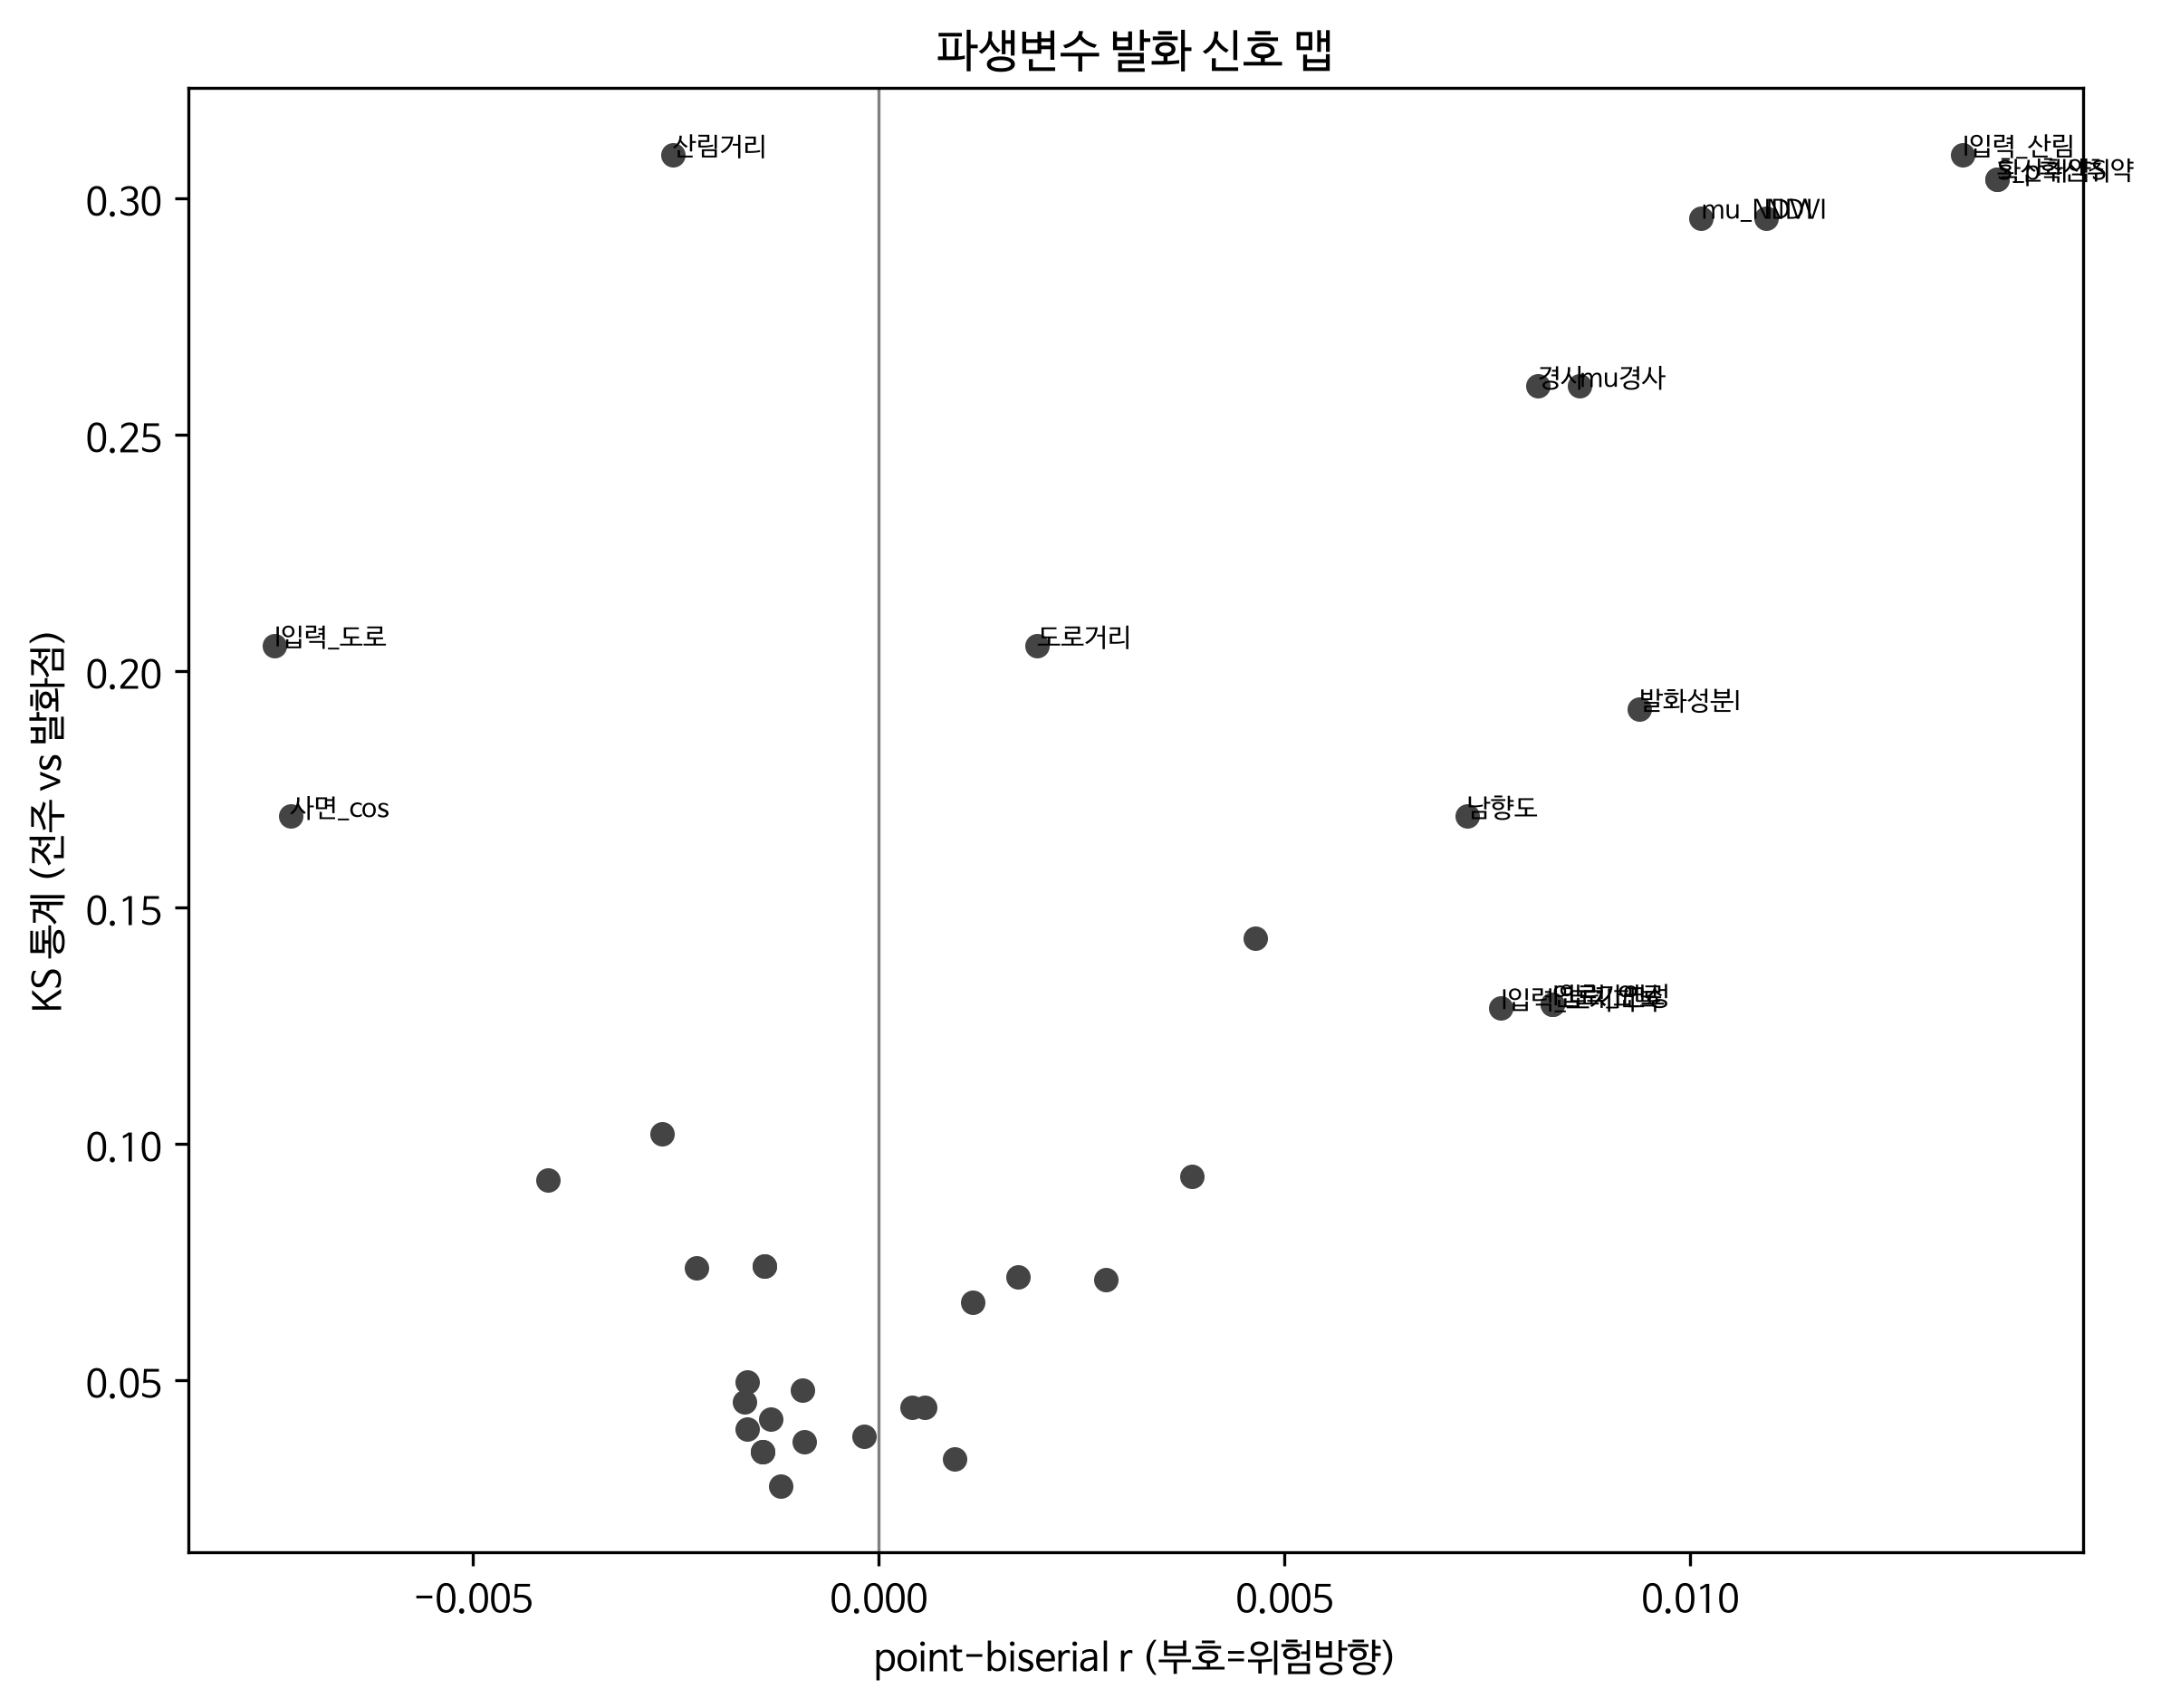

[발화 분리력 Top8 AUC-PR]


변수,그룹,point_biserial,KS,AUC_PR,lift_PR,recall_top1,recall_top5
str,str,f64,f64,f64,f64,f64,f64
"""S_p""","""사전엔지니어링(a)""",0.013782,0.304045,0.000914,1.851382,0.020438,0.105109
"""S""","""모델중간(b)""",0.013782,0.304045,0.000914,1.851382,0.020438,0.105109
"""mu_flammability""","""사전엔지니어링(a)""",0.008301,0.129434,0.000797,1.614471,0.035036,0.093431
"""f_fuel""","""I입력(b)""",0.008301,0.129434,0.000797,1.614471,0.035036,0.093431
"""f_landcover""","""I입력(b)""",0.007667,0.128635,0.000794,1.607745,0.017518,0.072993
"""ndvi""","""사전엔지니어링(a)""",0.010934,0.295807,0.000791,1.601945,0.016058,0.074453
"""mu_ndvi""","""사전엔지니어링(a)""",0.010137,0.295807,0.000789,1.599406,0.016058,0.074453
"""I""","""모델중간(b)""",0.009377,0.191897,0.000778,1.577113,0.021898,0.106569


In [4]:
s3 = E.section3_separability(cols, grp, D)
show('03_separability_aucpr.png', '03_signal_map.png')
print('[발화 분리력 Top8 AUC-PR]')
s3['table'].head(8)

## 4. 체제 차이 — 영동/영서/산간
MoE 정당성: 양간일·FWI·고도·연료가 체제마다 다른가.

[sec4] regime differences


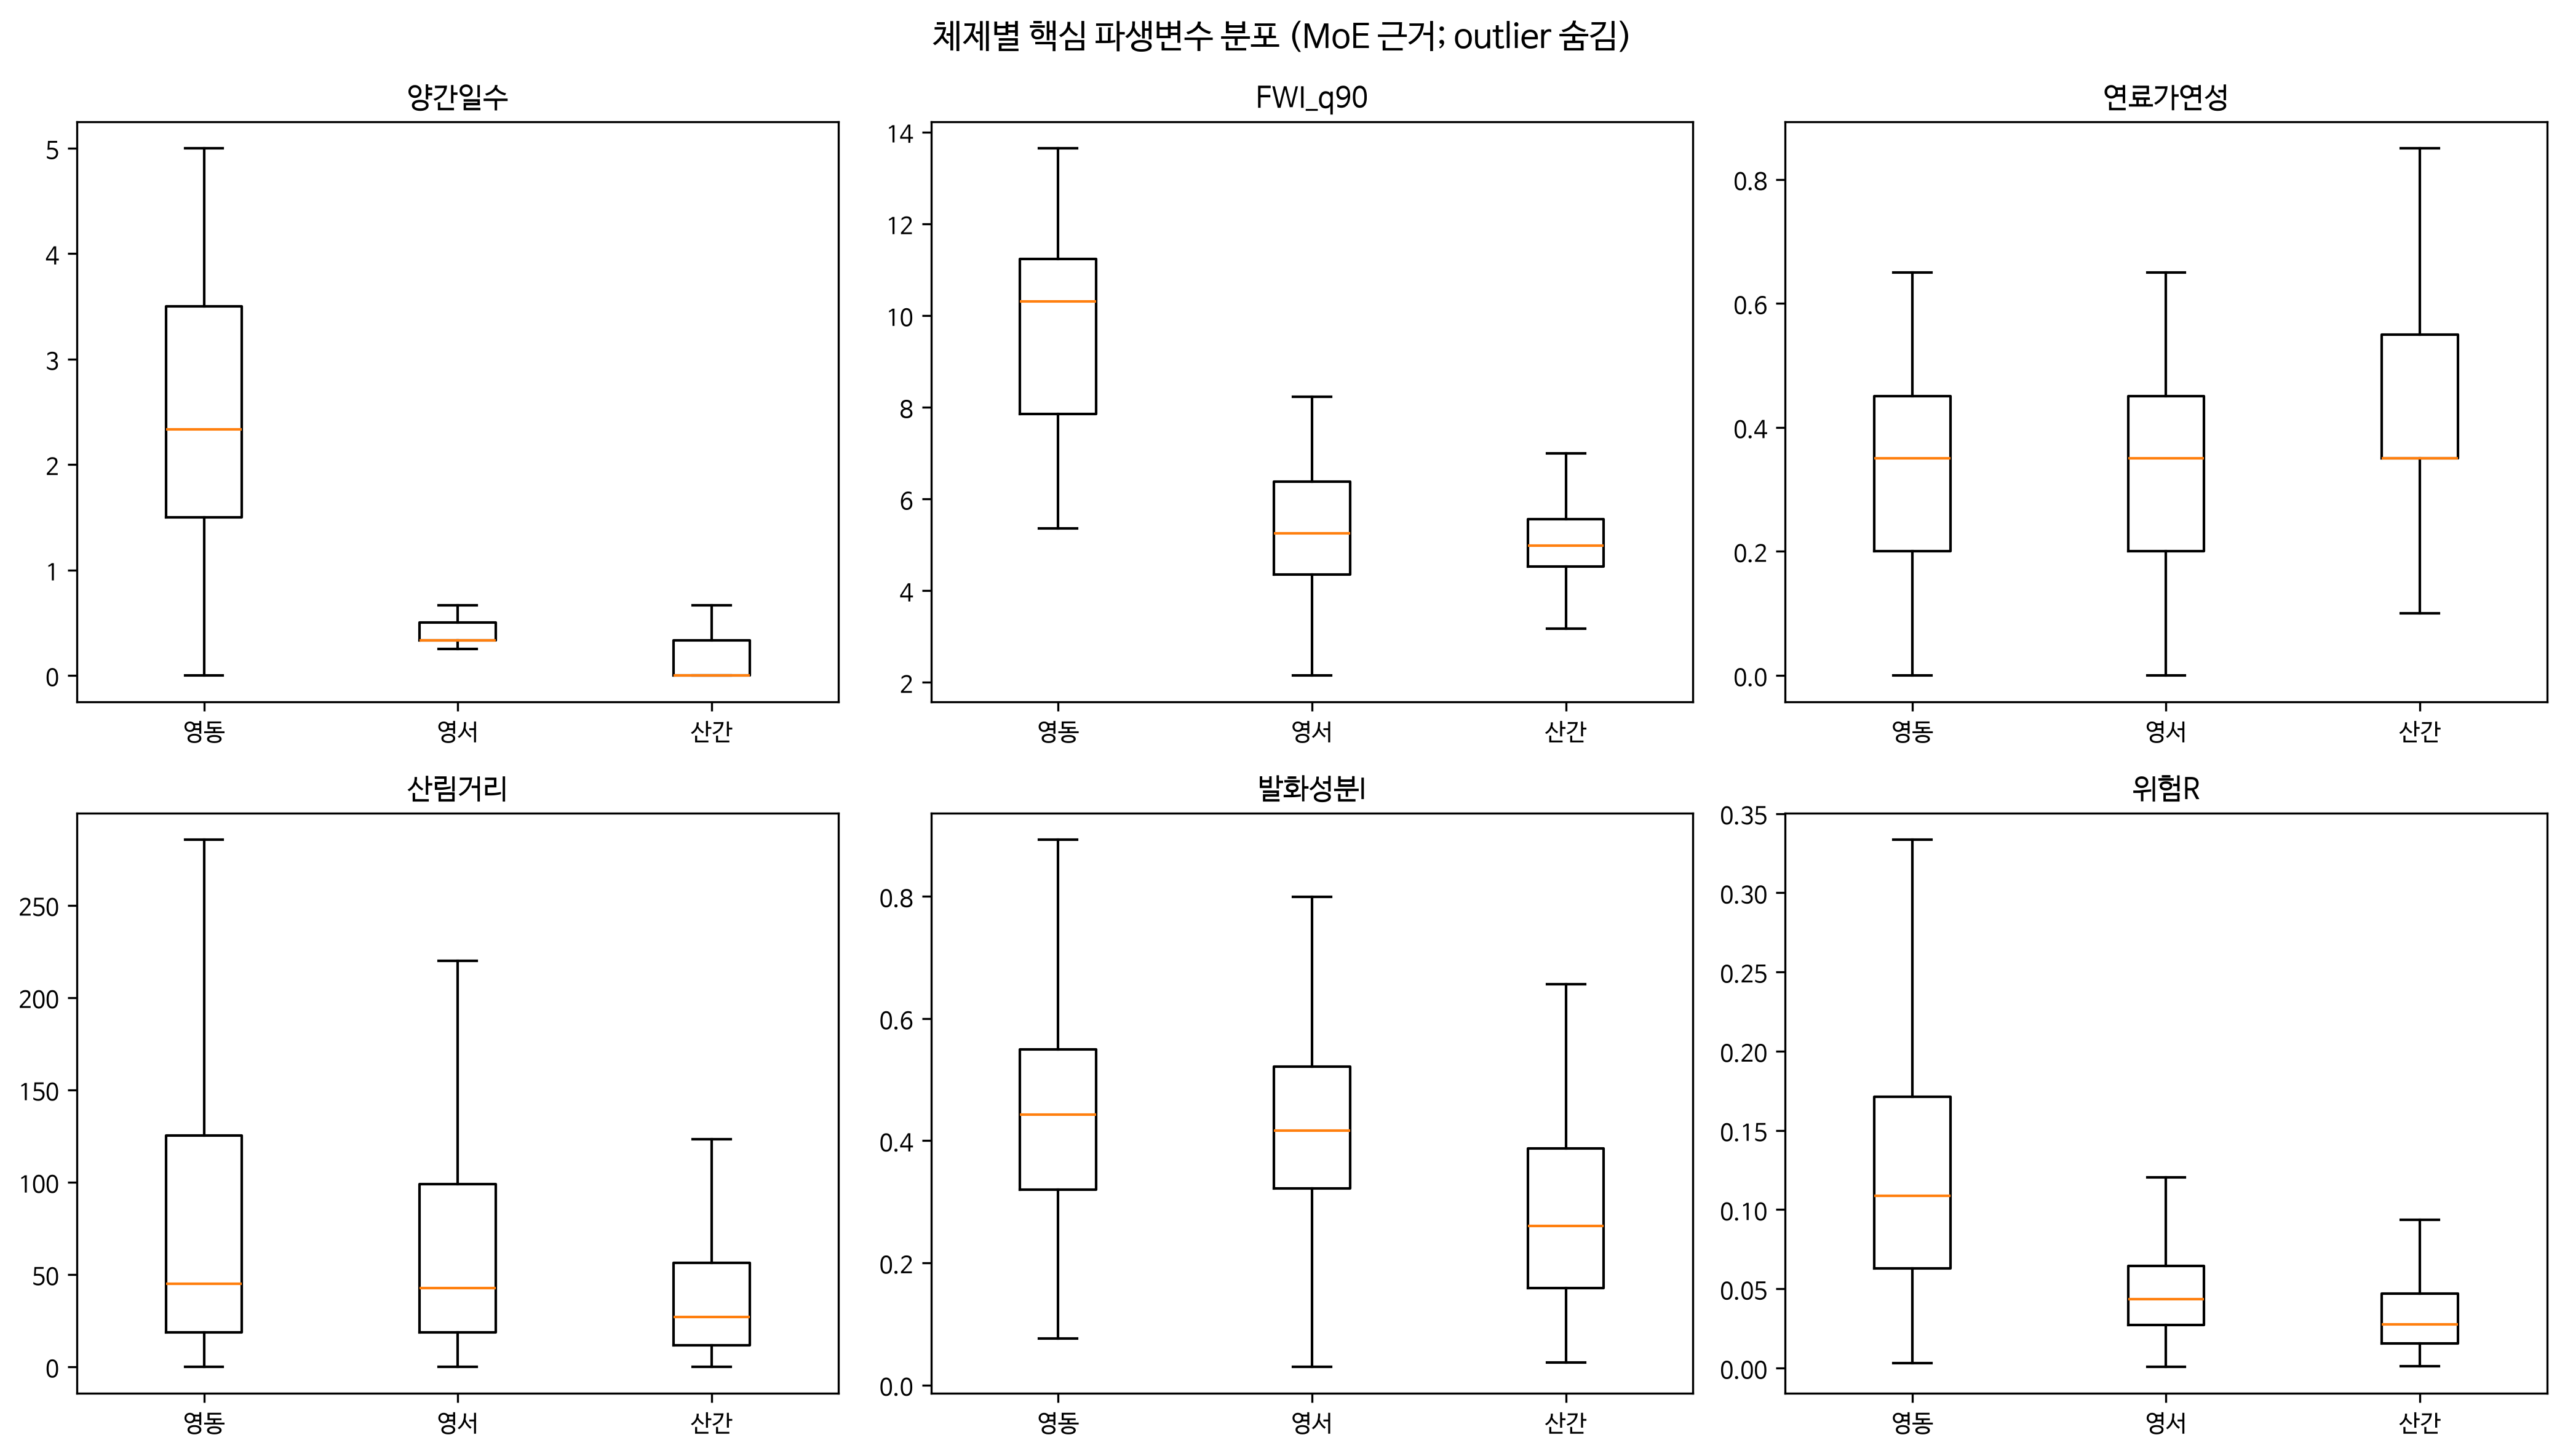

In [5]:
s4 = E.section4_regimes(cols, D)
show('04_regime_boxplots.png')

## 5. I·S·W 기여 분해 — 무엇이 R 을 지배하나 / 영동 쏠림 원인
전역 분산기여(I/S/W)와 체제간 평균차(영동 쏠림의 기계적 원인=W) 분리.

[sec5] I·S·W contribution to R


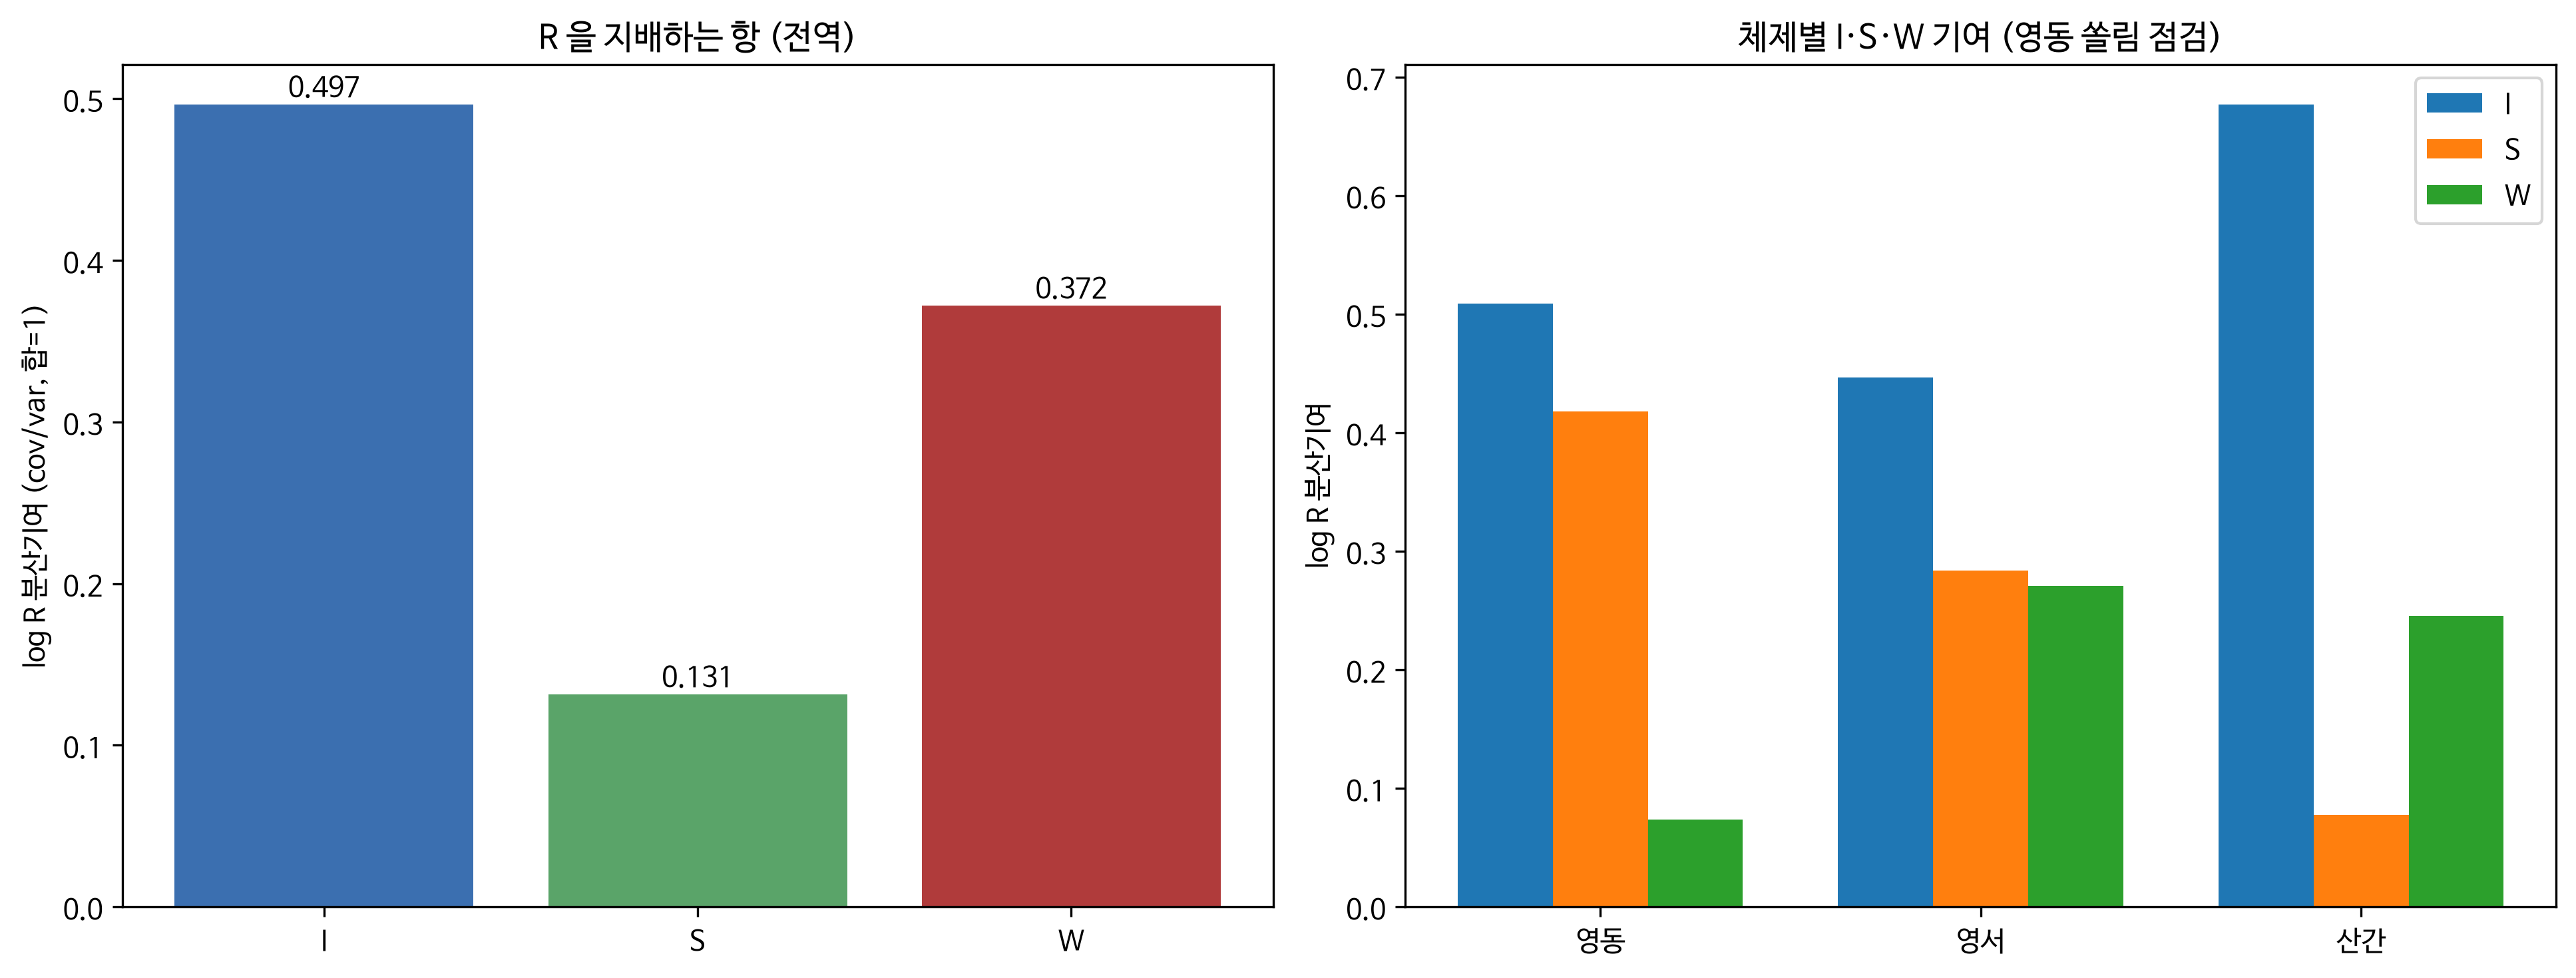

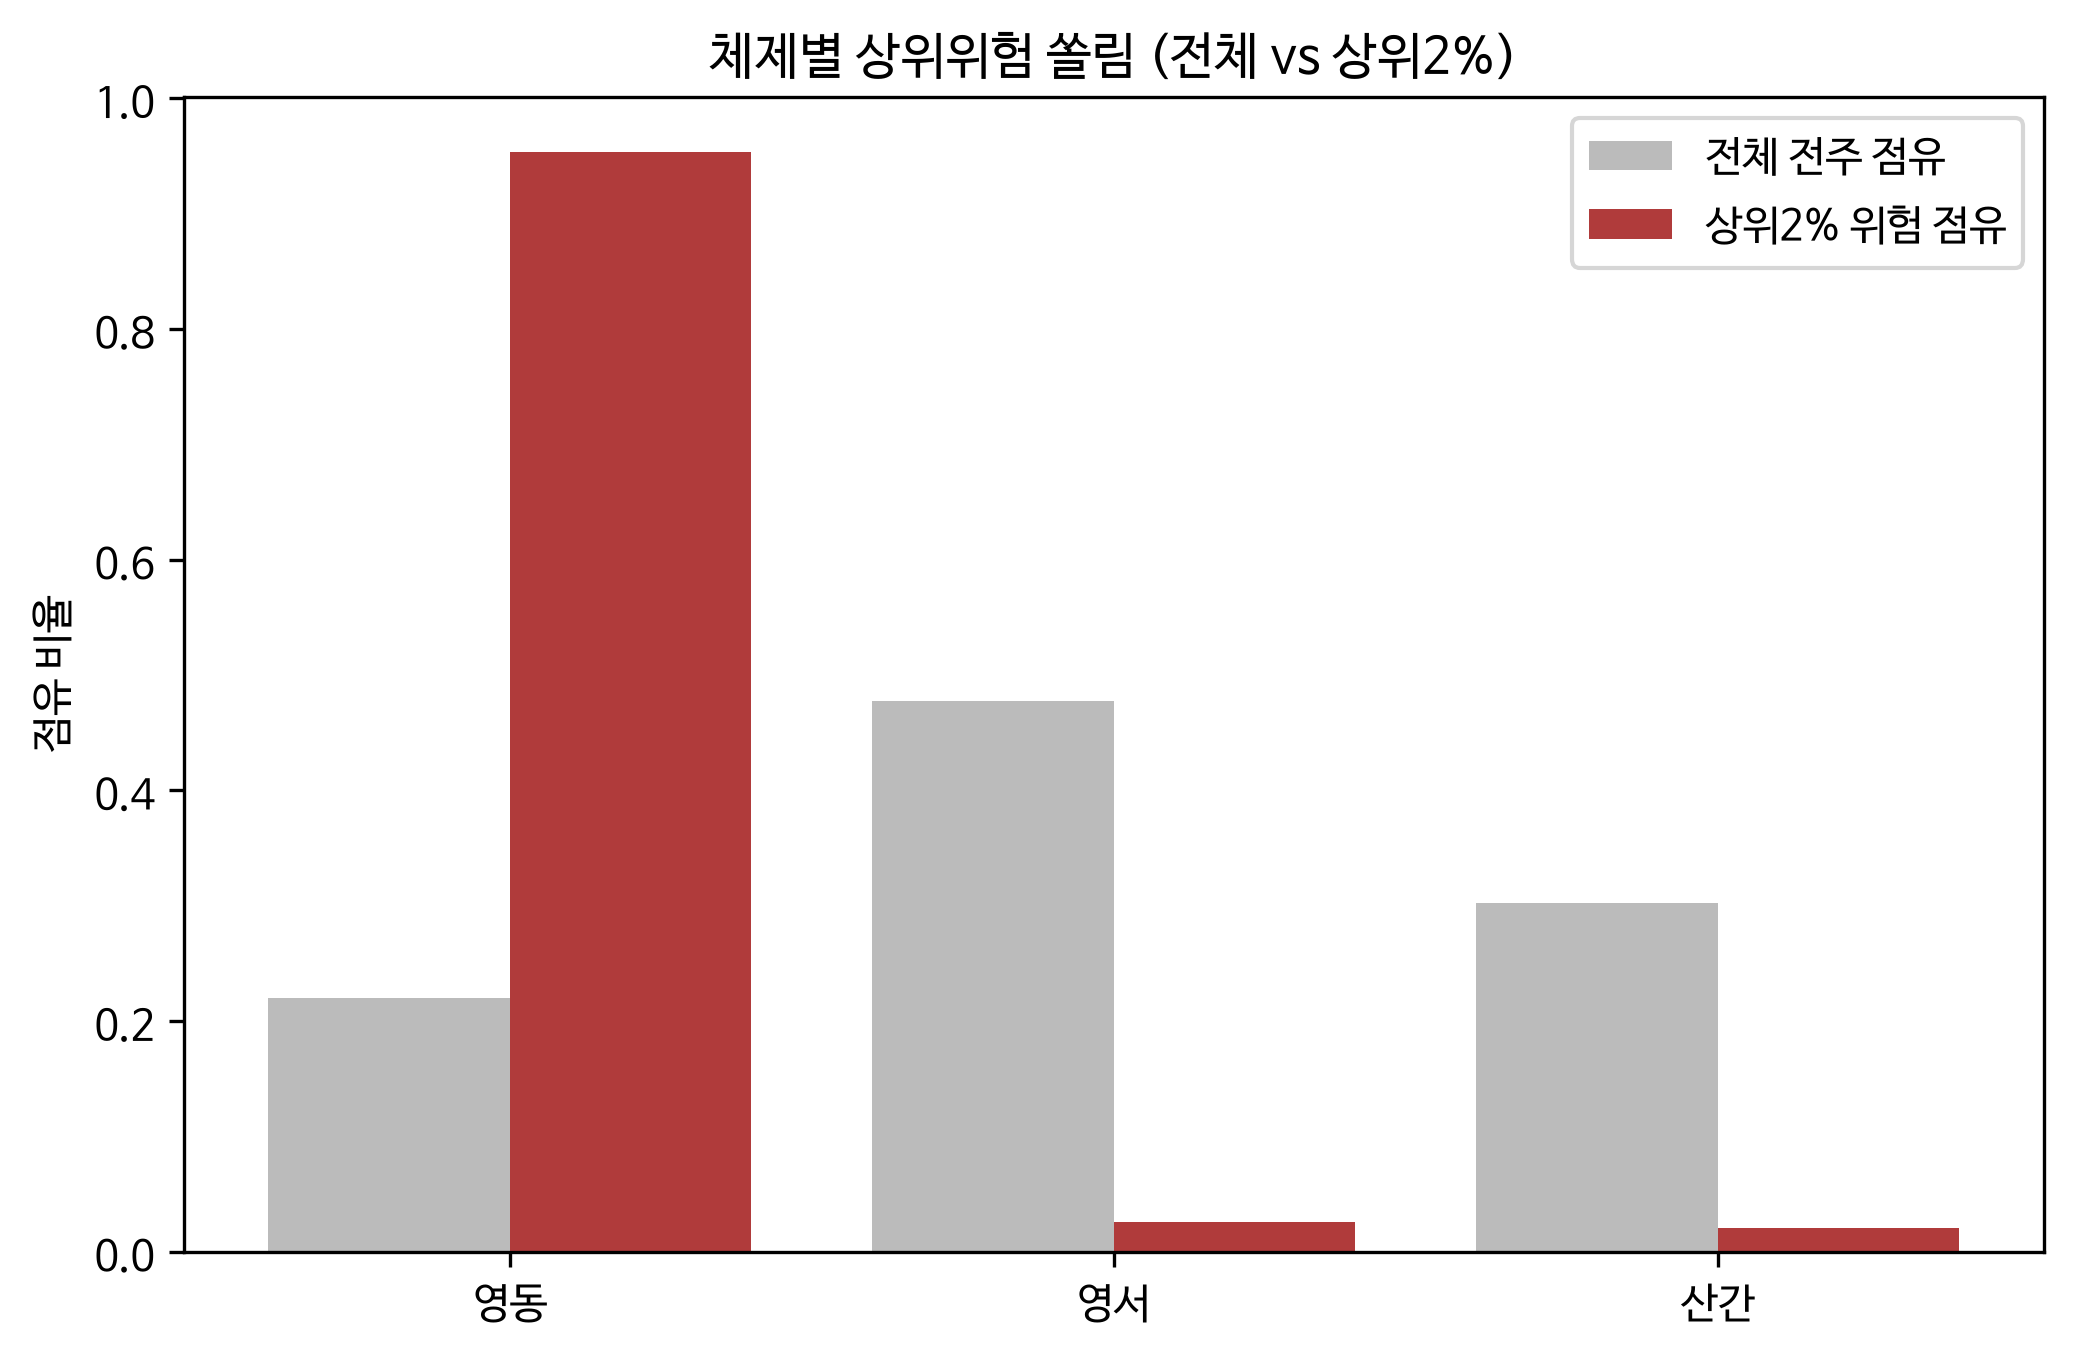

[R 분산기여] {'I': 0.497, 'S': 0.131, 'W': 0.372}
[영동] 인구비 0.22 → 상위2% 비중 0.954


In [6]:
s5 = E.section5_isw(D)
show('05_isw_contribution.png', '05_regime_topshare.png')
print('[R 분산기여]', {k: round(v,3) for k,v in s5['contrib'].items()})
print('[영동] 인구비', round(s5['pop_shares']['영동'],3), '→ 상위2% 비중', round(s5['top_shares']['영동'],3))

## 6. 공간 자기상관 (Moran's I)
risk_score·핵심변수의 공간 군집성 → 공간블록 CV 정당성.

[sec6] spatial autocorrelation (Moran's I)


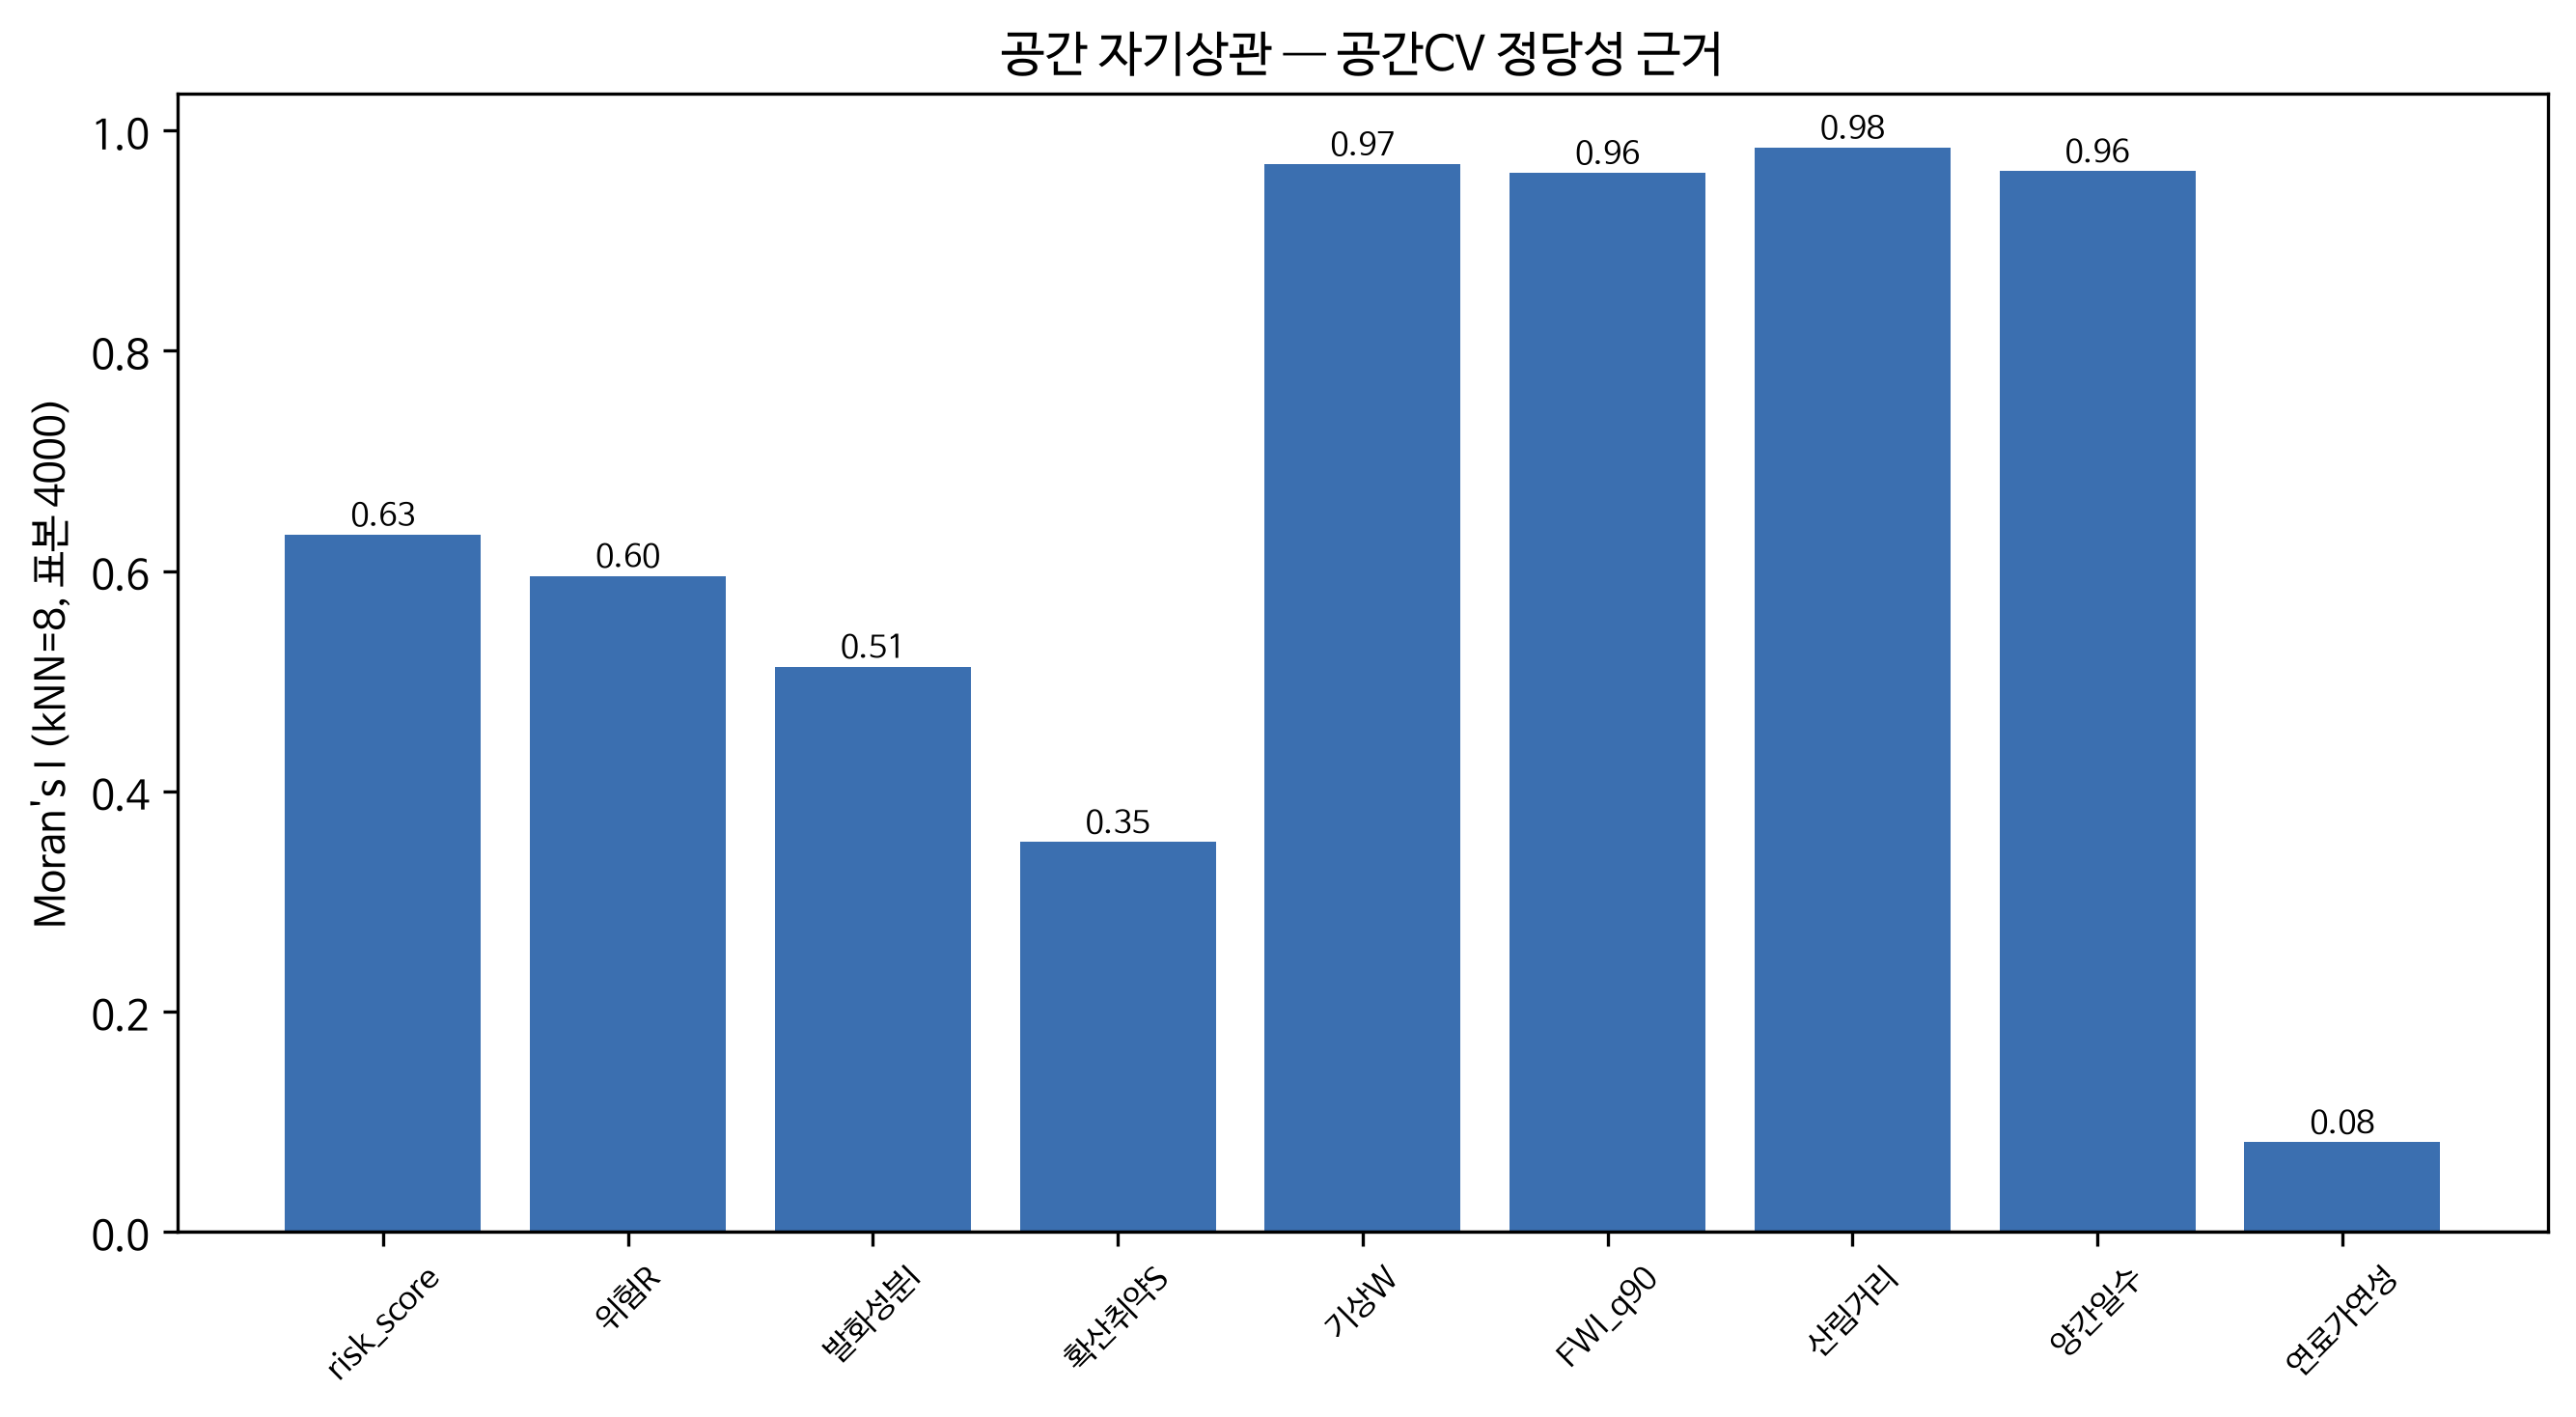

[Moran I] {'risk_score': 0.633, 'R': 0.596, 'I': 0.513, 'S': 0.354, 'W': 0.969, 'fwi_q90': 0.962, 'dist_to_forest': 0.984, 'yanggan_days': 0.963, 'mu_flammability': 0.081}


In [7]:
s6 = E.section6_moran(cols, D)
show('06_morans_i.png')
print('[Moran I]', {k: round(v,3) for k,v in s6['moran'].items()})

## 7. 불확실성 진단 — risk_lo/hi·cv·ops_priority
상대 불확실성·체제별 cv·`unc_lo` 퇴화 여부.

[sec7] uncertainty diagnostics


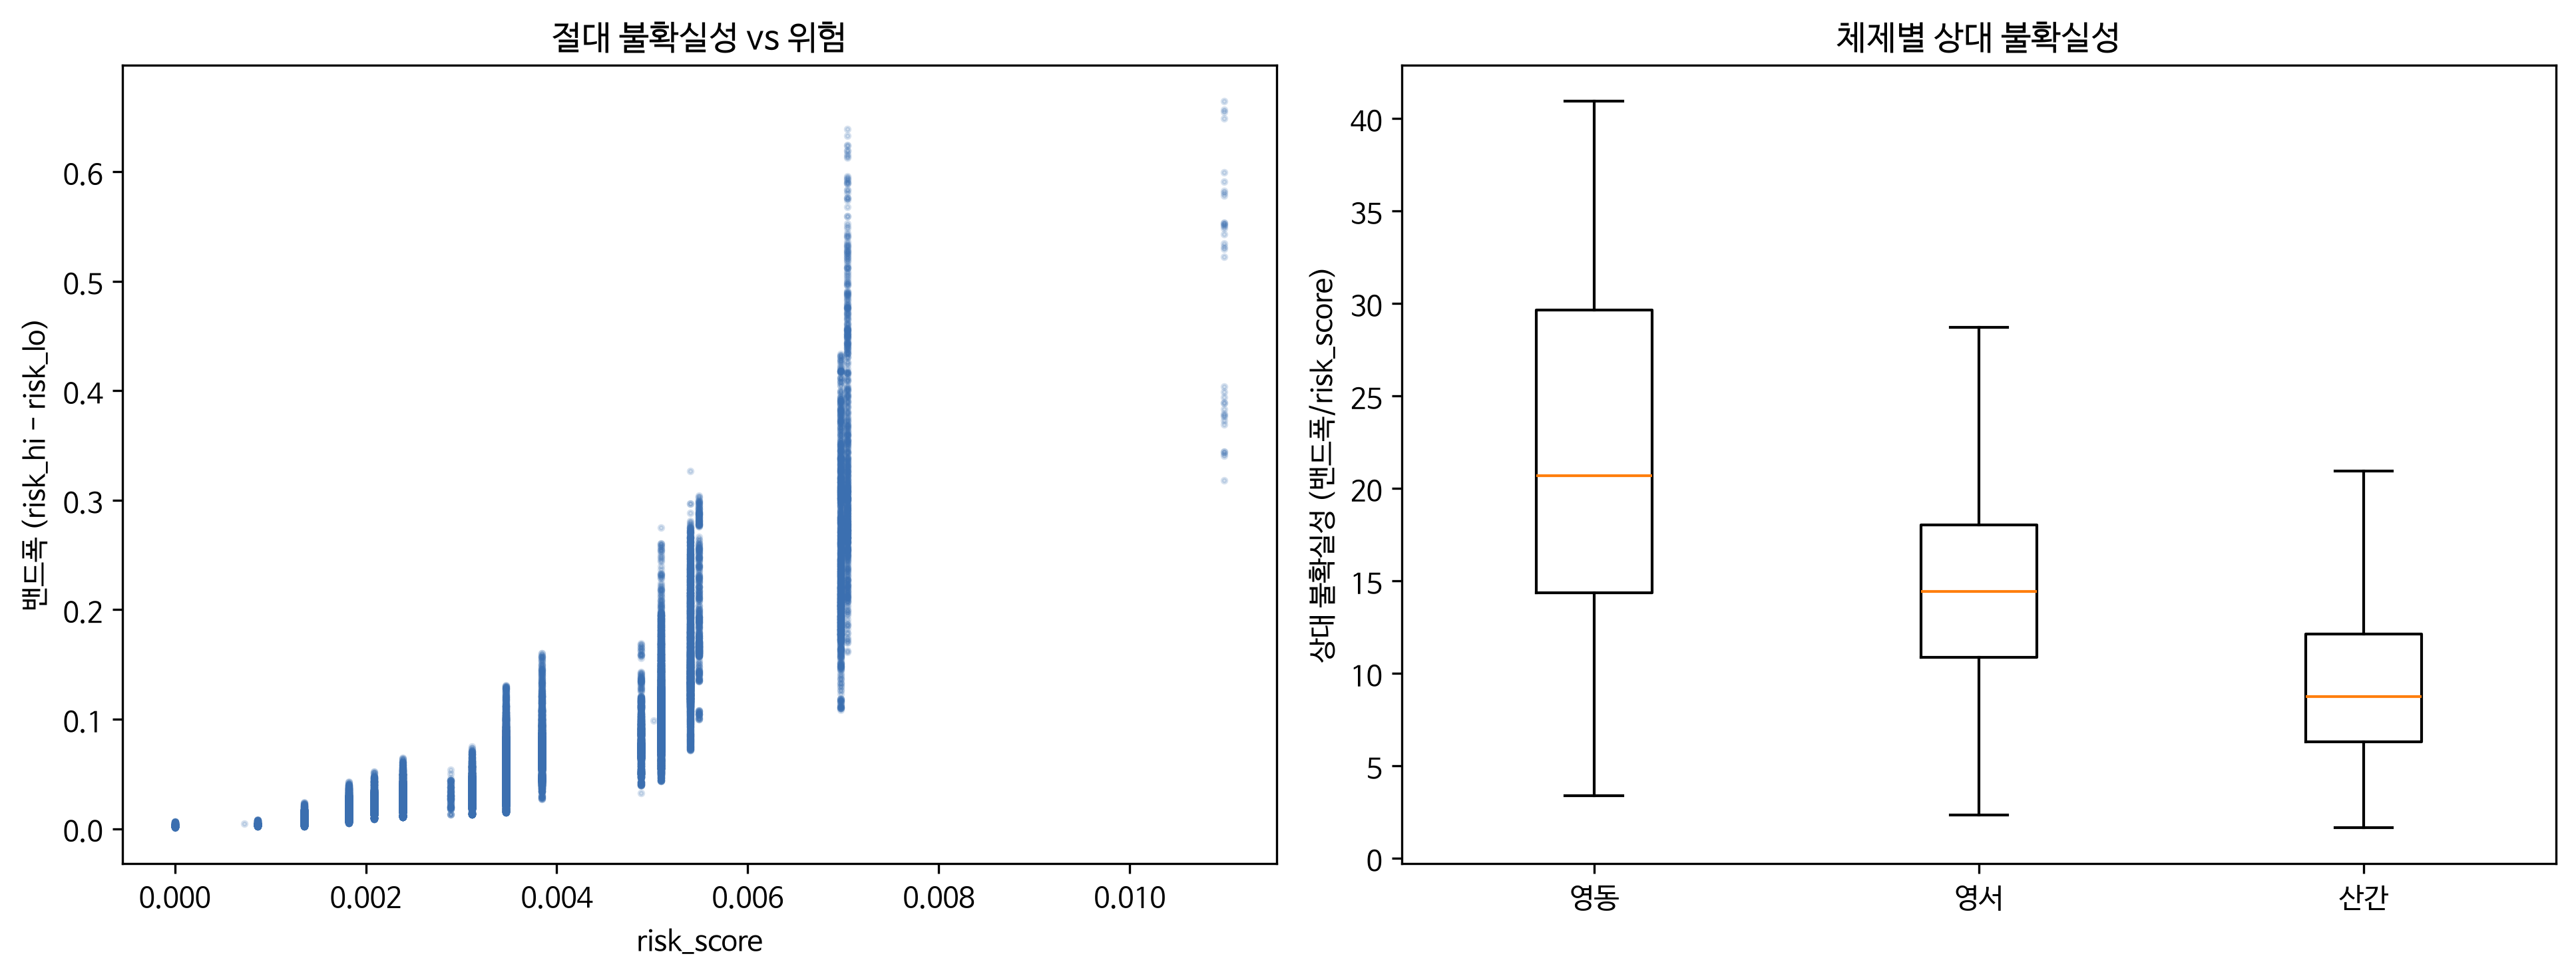

[unc_lo 퇴화(상수)] True


In [8]:
s7 = E.section7_uncertainty(cols, D)
show('07_uncertainty.png')
if not s7.get('skip'):
    print('[unc_lo 퇴화(상수)]', s7['unc_lo_degenerate'])

## 8. leakage / sanity — 제공 라벨 누수 점검
신뢰낮은 `training_labels`와 파생변수 상관 → 비정상 누수 징후 확인.

[sec8] leakage / sanity


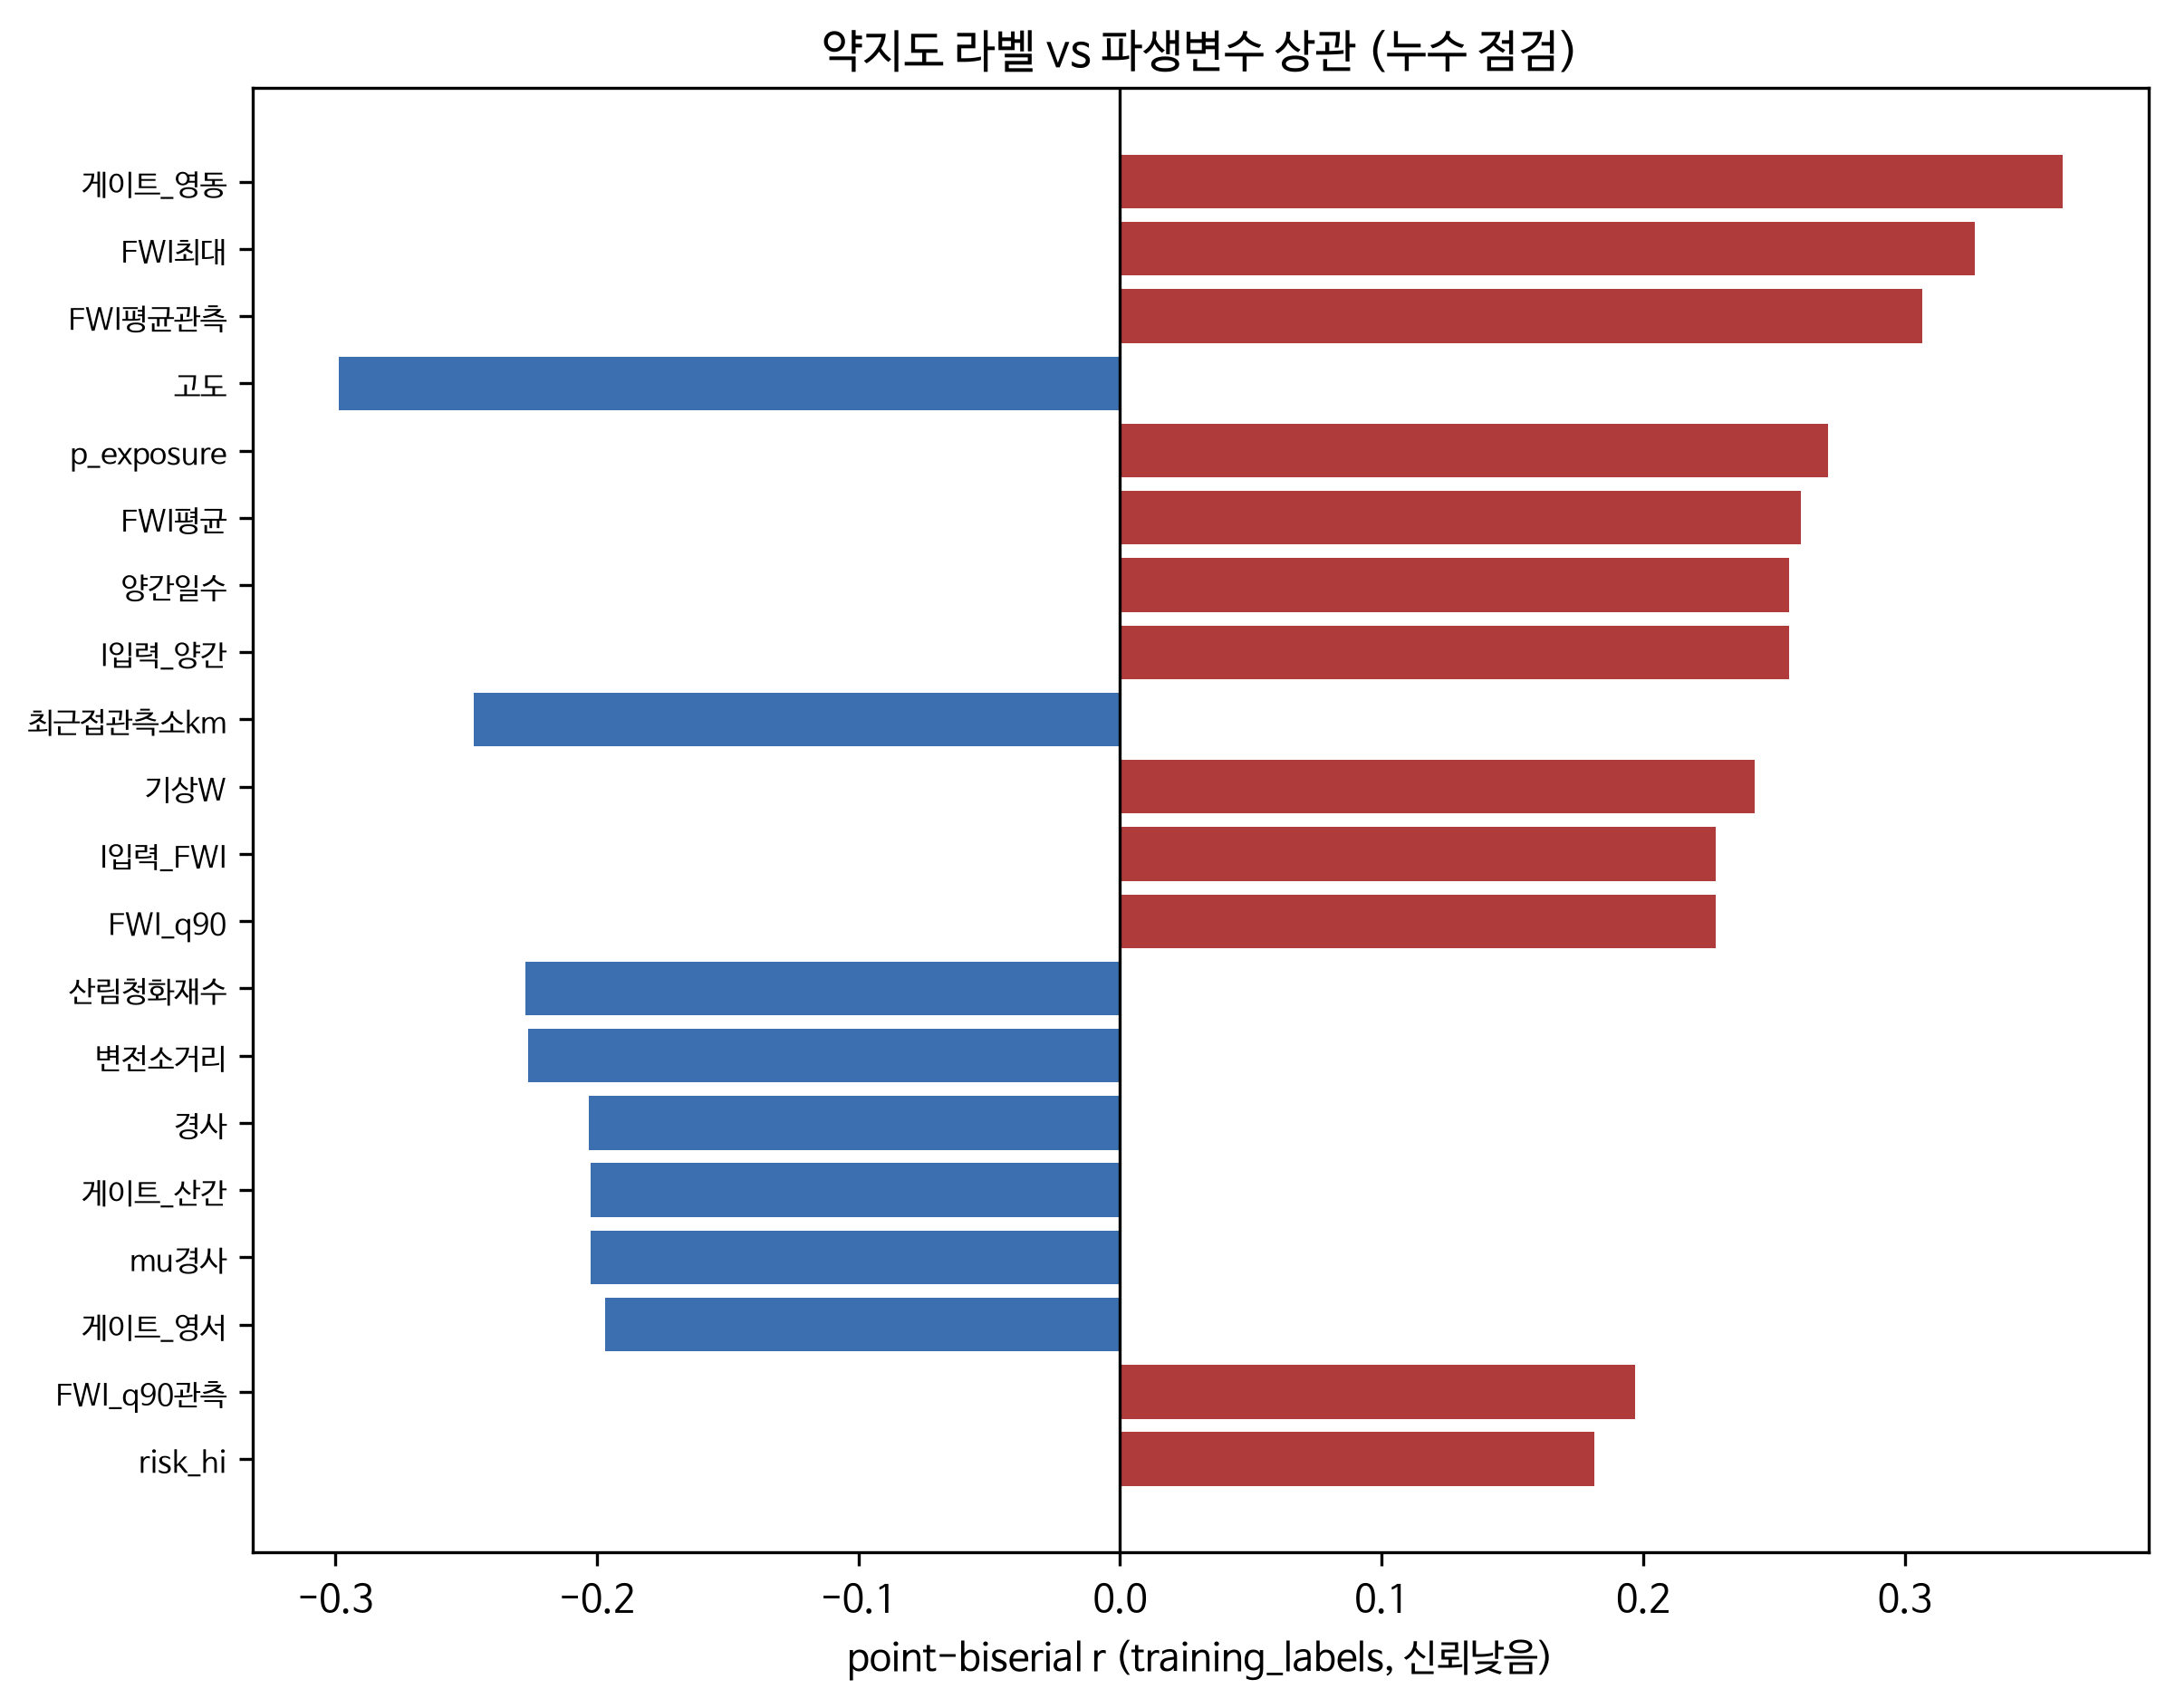

In [9]:
s8 = E.section8_leakage(cols, grp, D, s3['table'])
show('08_weaklabel_corr.png')

## 요약 · 모델 개선 권고
- **recall 천장 = 피처 한계**(단일 분리력 1.5~1.9×) — 모델 실패 아님.
- **영동 쏠림 = W**(fwi_q90·양간이 영동에서 2.4×) — 곱셈 R에서 쏠림 유발.
- **중복**: FWI 3종(VIF 38~69)·s2 → 대표 하나만.
- **버그**: `unc_lo` 상수0 → 제거/수정.

전체 수치 리포트: `claudedocs/eda_파생변수_심화_20260619.md`